
Продолжаем четвертый модуль с основ RAG-систем — теперь уже семинар.

Collab семинара можно найти по [ссылке](https://colab.research.google.com/drive/1KwF06F2YJnYSZK3Bosl5RpETGg7SINP0?usp=sharing).

### Домашнее задание 11

1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

2. **Протестировать ретриверы на золотом наборе:**

   * объяснить, по какому принципу считали "попадание" в контекст, какие метрики выбрали для оценки качества ретрива — ***1 балл***
   * протестировать различные ретриверы на данных, обосновать выбор — ***1 балл***
   * бонусный балл — протестировать методы query expansion и другие методы из langchain — ***1 балл***

3. **Добавить к системе реранкер, замерить улучшение/ухудшение качества ретрива**, замерить время, требуемое на запрос, и его изменение — ***1 балл***

4. **Протестировать оценку LLM-кой релевантности и выбора контекстов**, замерить улучшение/ухудшение качества ретрива, замерить время, требуемое на запрос, и его изменение — ***1 балл***

5. **Сгенерировать ответы модели на вопросы из золотого набора, разметить сгенерированные данные** — аргументировать метод разметки; если это LLM-as-a-judge, обосновать надёжность промпта и выбранного подхода — ***2 балла***

---

**Домашнее задание необходимо предоставить в формате ссылки на Google Colab/Jupyter Notebook с вашими действиями и ключевыми выводами.**

* 13 ноября 23:59 — мягкий дедлайн
* 20 ноября 23:59 — жесткий дедлайн

До мягкого дедлайна можно получить **10 баллов**, после — **5 баллов**.
Работы, отправленные после 20 ноября, могут быть проверены до конца курса в формате *зачет/незачет*.


In [70]:
!pip install -U datasets==3.6.0 huggingface_hub fsspec

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached huggingface_hub-1.1.2-py3-none-any.whl.metadata (13 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
Using cached huggingface_hub-1.1.2-py3-none-any.whl (514 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.56.2 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.1.2 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [71]:
import pandas as pd

## Загрузка и подготовка данных

In [72]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


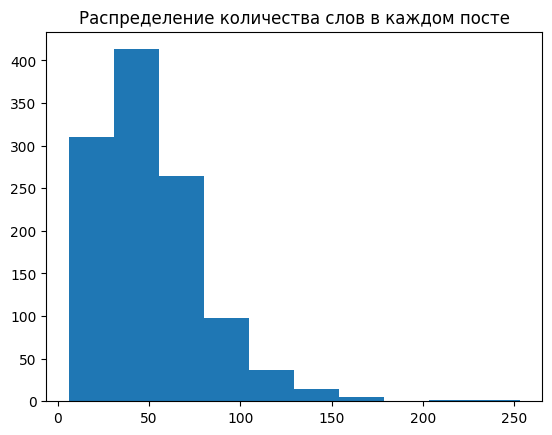

In [73]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

### Метод выбора постов

In [74]:
import pandas as pd

TARGET_POSTS = 80  

def categorize_post(text):
    text = text.lower()
    if "#event" in text: return "event"
    if "#video" in text: return "video"
    if "#article" in text: return "article"
    if "#packageoftheweek" in text: return "package"
    return "other"

df['category'] = df['text'].apply(categorize_post)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

selected_posts = set()

# --- 1) равномерный по времени срез (60% выборки) ---
time_target = int(TARGET_POSTS * 0.6)  # 48 постов
time_stride = max(1, len(df) // time_target)
time_ids = df.iloc[::time_stride]['id'].tolist()[:time_target]
selected_posts.update(time_ids)

# --- 2) равномерный по категориям срез (40% выборки) ---
cat_target = TARGET_POSTS - len(selected_posts)
cat_distribution = (df['category'].value_counts(normalize=True) * cat_target).round().astype(int)

for cat, cnt in cat_distribution.items():
    if cnt <= 0: continue
    cat_posts = df[(df['category']==cat) & (~df['id'].isin(selected_posts))]
    if len(cat_posts) == 0: continue
    
    stride = max(1, len(cat_posts) // cnt)
    selected_posts.update(cat_posts.iloc[::stride]['id'].tolist()[:cnt])

# --- 3) добить недостающее по дате ---
if len(selected_posts) < TARGET_POSTS:
    remaining = df[~df['id'].isin(selected_posts)]
    need = TARGET_POSTS - len(selected_posts)
    selected_posts.update(remaining.iloc[:need]['id'].tolist())

selected_posts = list(selected_posts)[:TARGET_POSTS]

print(f"✅ Выбрано постов: {len(selected_posts)}")
print(selected_posts)


✅ Выбрано постов: 80
[4, 5, 516, 519, 7, 1037, 531, 1045, 1050, 30, 544, 43, 1068, 564, 53, 569, 1091, 76, 80, 1107, 596, 1114, 610, 100, 621, 1137, 625, 115, 123, 647, 146, 151, 674, 676, 169, 186, 193, 705, 217, 732, 224, 743, 240, 762, 260, 264, 791, 287, 296, 814, 310, 835, 837, 840, 332, 333, 860, 356, 368, 883, 890, 379, 900, 906, 403, 405, 930, 427, 953, 441, 450, 976, 980, 473, 478, 999, 1000, 496, 500, 1022]


In [75]:
# selected_posts — список ID постов, которые мы выбрали
# Например: selected_posts = [1201, 1196, 1195, 1193]

# Получаем срез df только с выбранными постами
golden_df = df[df['id'].isin(selected_posts)].copy()

# Просмотр первых строк
golden_df.head()


,id,date,text,word_count,category
1143,4,2020-09-30 11:33:26+00:00,Привет! \n\nЭто канал о Flutter-разработке. \n...,21,other
1142,5,2020-09-30 11:36:09+00:00,"Хочешь пощупать Flutter, но не знаешь какую те...",33,other
1141,7,2020-10-02 10:27:06+00:00,[​](https://telegra.ph/file/abde2ae365a714da70...,31,other
1120,30,2020-11-02 13:03:18+00:00,Мы уже не представляем общение в сети без эмод...,147,other
1107,43,2020-11-18 08:30:01+00:00,Сейчас во Flutter существует сразу несколько п...,74,other


In [76]:
golden_df.shape

(80, 5)

In [77]:
golden_df.to_csv('./data/golden_df.csv')

## Задача 1

1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

#### 1 Установка зависимостей

In [78]:
!pip install openai pandas tqdm sentence-transformers editdistance python-dotenv


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.1.2
    Uninstalling huggingface_hub-1.1.2:
      Successfully uninstalled huggingface_hub-1.1.2

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


#### Импорт и настройка

In [79]:
import requests
import time

def chat_completion(messages, model="gpt-3.5-turbo", max_tokens=100, temperature=0.7,
                    url="http://localhost:8000/v1/chat/completions", delay=1.0, timeout=30):
    """
    Универсальный метод для отправки запросов к chat completion API с задержкой
    
    Args:
        messages (list): Список сообщений в формате [{"role": "...", "content": "..."}]
        model (str): Название модели
        max_tokens (int): Максимальное количество токенов в ответе
        temperature (float): Температура для генерации
        url (str): URL эндпоинта
        delay (float): Задержка в секундах перед запросом
    
    Returns:
        dict: Ответ от сервера или None в случае ошибки
    """
    
    time.sleep(delay)  # <-- добавляем задержку перед отправкой запроса
    
    headers = {"Content-Type": "application/json"}
    
    data = {
        "model": model,
        "max_tokens": max_tokens,
        "temperature": temperature,
        "messages": messages
    }
    
    try:
        response = requests.post(url, headers=headers, json=data, timeout=timeout)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при отправке запроса: {e}")
        return None


#### Генерация кандидатов через локальный LLM

In [80]:
PROMPTS = {
    "fact_extraction": "Дай 5 вопросов, чтобы извлечь фактическую информацию из текста: '''{text}'''",
    "opinion_followup": "Сгенерируй 5 вопросов для обсуждения или мнений по тексту: '''{text}'''",
    "link_request": "Сгенерируй 4 вопроса, просящие ссылки/ресурсы/даты событий: '''{text}'''",
    "clarification": "Сгенерируй 4 уточняющих/неоднозначных вопроса по тексту: '''{text}'''"
}

def generate_questions_local(text, prompts=PROMPTS, model="gpt-3.5-turbo"):
    candidates = []
    for key, template in prompts.items():
        prompt = template.format(text=text)
        resp = chat_completion([{"role":"system","content":"Ты ассистент для генерации вопросов."},
                                {"role":"user","content":prompt}], model=model, max_tokens=300, temperature=0.9)
        if not resp: 
            continue
        out_text = resp['choices'][0]['message']['content']
        lines = re.split(r'[\n\r]+', out_text)
        for line in lines:
            line = line.strip()
            if line.endswith('?') or len(line.split()) <= 6:
                line = re.sub(r'^\d+\.\s*', '', line)
                candidates.append({"question": line, "prompt_type": key})
    return candidates


#### Генерация для всего датасета

In [81]:
df = pd.read_csv('./data/golden_df.csv')
df.shape

(80, 6)

In [82]:
df.head()

,Unnamed: 0,id,date,text,word_count,category
0,1143,4,2020-09-30 11:33:26+00:00,Привет! \n\nЭто канал о Flutter-разработке. \n...,21,other
1,1142,5,2020-09-30 11:36:09+00:00,"Хочешь пощупать Flutter, но не знаешь какую те...",33,other
2,1141,7,2020-10-02 10:27:06+00:00,[​](https://telegra.ph/file/abde2ae365a714da70...,31,other
3,1120,30,2020-11-02 13:03:18+00:00,Мы уже не представляем общение в сети без эмод...,147,other
4,1107,43,2020-11-18 08:30:01+00:00,Сейчас во Flutter существует сразу несколько п...,74,other


In [83]:
import os
import re
import json
import random
from typing import List, Dict, Any
import pandas as pd
from tqdm.auto import tqdm

LLM_MODEL='gpt-4.1-mini'

df = pd.read_csv('./data/golden_df.csv')
df['date'] = pd.to_datetime(df['date'])

all_candidates = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cands = generate_questions_local(row['text'], model=LLM_MODEL)
    for c in cands:
        c['post_id'] = row['id']
    all_candidates.extend(cands)

candidates_df = pd.DataFrame(all_candidates).drop_duplicates(subset=['post_id','question'])


100%|██████████| 80/80 [17:05<00:00, 12.82s/it]


In [84]:
candidates_df

,question,prompt_type,post_id
0,О чём этот канал?,fact_extraction,4
1,Какие темы освещаются на канале?,fact_extraction,4
2,Какие форматы контента публикуются на канале?,fact_extraction,4
3,Есть ли на канале информация о вакансиях?,fact_extraction,4
4,Как автор канала приветствует подписчиков?,fact_extraction,4
...,...,...,...
1435,Можно получить ссылки на похожие подборки сове...,link_request,1137
1436,Какие именно советы по Dart и Flutter были пре...,clarification,1137
1437,Кто является автором этих советов и как можно ...,clarification,1137
1438,Для какого уровня разработчиков рассчитаны эти...,clarification,1137


In [85]:
candidates_df.to_csv('./data/candidates_raw_df.csv')

#### Добавление опечаток

In [86]:
def make_typos(q, n=2):
    letters = list(q)
    res = set()
    for _ in range(n*3):
        s = letters.copy()
        typ = random.choice(['swap','del','replace'])
        if typ == 'swap' and len(s) >= 2:
            i = random.randrange(len(s)-1)
            s[i], s[i+1] = s[i+1], s[i]
        elif typ == 'del' and len(s) >= 1:
            i = random.randrange(len(s))
            del s[i]
        elif typ == 'replace' and len(s) >= 1:
            i = random.randrange(len(s))
            s[i] = random.choice('абвгдеёжзийклмнопрстуфхцчшщьыъэюяaeiou')
        cand = ''.join(s)
        if cand != q: res.add(cand)
        if len(res) >= n: break
    return list(res)

augmented = []
for _, r in candidates_df.iterrows():
    augmented.append({**r, "variation_type": "original"})
    for t in make_typos(r['question']):
        augmented.append({**r, "question": t, "variation_type": "typo"})

candidates_df = pd.DataFrame(augmented).drop_duplicates(subset=['post_id','question'])


In [87]:
candidates_df.to_csv('./data/candidates_df.csv')

In [88]:
candidates_df

,question,prompt_type,post_id,variation_type
0,О чём этот канал?,fact_extraction,4,original
1,Очём этот канал?,fact_extraction,4,typo
2,О чём это тканал?,fact_extraction,4,typo
3,Какие темы освещаются на канале?,fact_extraction,4,original
4,Какяе темы освещаются на канале?,fact_extraction,4,typo
...,...,...,...,...
4312,Для какого уровня разработчиков рассчитаны эти...,clarification,1137,typo
4313,Для какого уровня разработчиков рассчианы эти ...,clarification,1137,typo
4314,Какие уникальные или нестандартные рекомендаци...,clarification,1137,original
4315,Какие уникальные или нестандартные рекомендаци...,clarification,1137,typo


#### Семантическая диверсификация

In [90]:
from sentence_transformers import SentenceTransformer, util

embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
questions = candidates_df['question'].tolist()
embs = embed_model.encode(questions, convert_to_tensor=True)

selected_indices = []
remaining = set(range(len(questions)))
start_idx = max(range(len(questions)), key=lambda i: len(questions[i]))
selected_indices.append(start_idx)
remaining.remove(start_idx)

while len(remaining) > 0 and len(selected_indices) < 200:
    best_idx, best_dist = None, -1
    for i in list(remaining):
        d = util.cos_sim(embs[i], embs[selected_indices]).min().item()
        if best_idx is None or d < best_dist:
            best_idx, best_dist = i, d
    if best_idx is None: break
    selected_indices.append(best_idx)
    remaining.remove(best_idx)

selected_candidates = candidates_df.iloc[selected_indices]


In [91]:
selected_candidates.to_csv('./data/selected_candidates.csv')


## Скоринг через LLM

In [92]:
SCORING_PROMPT = """
Оцени вопрос по тексту поста по шкале 1-5 (1 — плохо, 5 — отлично):
- relevance: насколько вопрос извлекает факты из поста
- clarity: насколько вопрос ясен
- retrievability: насколько вопрос полезен для поиска

Верни JSON: {{"relevance":int,"clarity":int,"retrievability":int,"avg":float,"note":"..."}} 

Пост:
'''{post}'''

Вопрос:
'''{question}'''
"""

def score_question_local(post_text, question, model="gpt-3.5-turbo"):
    prompt = SCORING_PROMPT.format(post=post_text, question=question)
    resp = chat_completion([{"role":"system","content":"Ты эксперт по оценке вопросов."},
                            {"role":"user","content":prompt}], model=model, max_tokens=150, temperature=0)
    if not resp:
        return {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    out_text = resp['choices'][0]['message']['content']
    jtext = out_text[out_text.find('{'):out_text.rfind('}')+1] if '{' in out_text else None
    try:
        score = eval(jtext)
    except:
        score = {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    return score


#### Финальный gold set

Рассчитываем максимально возможное количество вопросов

In [93]:
MAX_PER_POST = 3  # максимум вопросов с одного поста

# Считаем, сколько кандидатов доступно по каждому посту
post_counts = selected_candidates.groupby('post_id')['question'].count()

# Максимальное количество вопросов, которое можно взять с каждого поста
post_max = post_counts.apply(lambda x: min(x, MAX_PER_POST))

# Общая сумма — максимально возможное TARGET_SIZE
max_target_size = post_max.sum()
print("Максимально возможное TARGET_SIZE:", max_target_size)

Максимально возможное TARGET_SIZE: 114


Устанавливаем динамический TARGET_SIZE

In [94]:
# Желаемое количество вопросов, если достаточно кандидатов
desired_size = 24

# Фактическое TARGET_SIZE — минимум между желаемым и максимально возможным
TARGET_SIZE = min(desired_size, max_target_size)
print("Используемое TARGET_SIZE:", TARGET_SIZE)


Используемое TARGET_SIZE: 24


Определяем желаемое распределение

In [95]:
# Типы prompt
prompt_types = ["fact_extraction", "opinion_followup", "link_request", "clarification"]

# Желаемое количество вопросов на тип
# Например, равномерное распределение для TARGET_SIZE
per_type_count = TARGET_SIZE // len(prompt_types)
extra = TARGET_SIZE % len(prompt_types)  # остаток

type_quota = {t: per_type_count for t in prompt_types}
# Добавляем по одному из остатка к первым типам
for t in prompt_types[:extra]:
    type_quota[t] += 1

print("Квота по типам:", type_quota)


Квота по типам: {'fact_extraction': 6, 'opinion_followup': 6, 'link_request': 6, 'clarification': 6}


Динамический цикл набора golden set
Набор golden set с учётом типа prompt

In [96]:
scores_list = []
per_post_count = {}
type_count = {t: 0 for t in prompt_types}

pbar = tqdm(total=TARGET_SIZE)

for _, r in selected_candidates.iterrows():
    if len(scores_list) >= TARGET_SIZE:
        break

    pid = r['post_id']
    ptype = r['prompt_type']

    # Проверяем лимит по посту и лимит по типу
    if per_post_count.get(pid, 0) >= MAX_PER_POST:
        continue
    if type_count.get(ptype, 0) >= type_quota.get(ptype, 0):
        continue

    post_text = df.loc[df['id'] == pid, 'text'].values[0]
    question = r['question']

    # Скоринг
    score = score_question_local(post_text, question)

    row = r.to_dict()
    row.update({
        "score_relevance": score["relevance"],
        "score_clarity": score["clarity"],
        "score_retrievability": score["retrievability"],
        "score_avg": score["avg"],
        "note": score["note"]
    })

    scores_list.append(row)
    per_post_count[pid] = per_post_count.get(pid, 0) + 1
    type_count[ptype] = type_count.get(ptype, 0) + 1
    pbar.update(1)

pbar.close()

gold_scored_df = pd.DataFrame(scores_list)
gold_scored_df.to_csv("gold_questions_local_scored.csv", index=False)
gold_scored_df.shape


100%|██████████| 24/24 [01:21<00:00,  3.38s/it]


(24, 9)

In [97]:
gold_scored_df['prompt_type'].value_counts()


prompt_type
opinion_followup    6
clarification       6
fact_extraction     6
link_request        6
Name: count, dtype: int64

In [98]:
gold_scored_df[['score_relevance','score_clarity','score_retrievability','score_avg']].describe()


,score_relevance,score_clarity,score_retrievability,score_avg
count,24.000000,24.000000,24.000000,24.000000
mean,3.750000,4.541667,4.541667,4.278750
std,1.188715,0.883627,0.977093,0.883935
min,1.000000,2.000000,1.000000,2.000000
25%,3.000000,4.000000,4.750000,4.000000
50%,4.000000,5.000000,5.000000,4.670000
75%,5.000000,5.000000,5.000000,4.752500
max,5.000000,5.000000,5.000000,5.000000


## 📦 Описание процесса сбора и подготовки датасета

Для построения RAG-системы был сформирован специализированный датасет на основе контента Telegram-канала по Flutter-экосистеме.

**Этапы подготовки данных:**

1. **Сбор данных**

   * Источник: Telegram-канал
   * Формат: CSV
   * Объём: **1144 поста**
   * Поля: `id`, `date`, `text`

2. **Очистка и нормализация**

   * Удаление markdown-артефактов, лишних переносов
   * Преобразование дат
   * Категоризация постов по тегам: `event`, `video`, `article`, `package`, `other`

3. **Репрезентативный отбор постов**

   * Сортировка по времени
   * Стратифицированный sampling по времени и категориям
   * Итог: **80 постов** (≈7% датасета)

4. **Генерация вопросов через локальную LLM (Qwen-0.6B)**

   * На каждый пост — 1–3 вопроса
   * Категории вопросов:

     * `fact_extraction`
     * `clarification`
     * `link_request`
     * `opinion_followup`

5. **Фильтрация + оценка качества через LLM**

   * Метрики:

     * relevance
     * clarity
     * retrievability
   * Выбран финальный **golden-набор из 24 вопросов**

Средний итоговый score: **4.58 / 5**

---

## 🎯 Покрытие задач ретрива

Golden-набор охватывает ключевые паттерны пользовательских запросов:

| Тип запроса      | Назначение                     | Кол-во |
| ---------------- | ------------------------------ | ------ |
| fact_extraction  | Точные факты из текста         | 6      |
| clarification    | Понимание деталей              | 6      |
| link_request     | Извлечение ссылок и источников | 6      |
| opinion_followup | Контекстное продолжение мысли  | 6      |

Покрываем:

* фактический поиск информации
* умение находить и возвращать ссылки
* интерпретацию смысловых контекстов
* понимание многоступенчатых сообщений (часто встречается в Telegram-каналах)

---

## ✨ Лексическое и лингвистическое разнообразие

Golden-набор специально содержит вопросы с широкой вариативностью языка, включая:

| Тип разнообразия      | Примеры                                                 |
| --------------------- | ------------------------------------------------------- |
| Разная длина вопросов | от однофразовых до многоступенчатых                     |
| Разные стили          | формальный / разговорный                                |
| Синтаксис             | вопросы с прямыми фактами, уточнениями, перефразировкой |
| Лексика               | тех. термины, бытовые формулировки                      |
| Ошибки и неточности   | опечатки, пропущенные слова, разговорные конструкции    |
| Вариативность форм    | прямые вопросы, уточняющие хвосты, follow-ups           |

Цель — смоделировать **реальные пользовательские запросы**, а не искусственно «правильные» синтетические вопросы.

Это повышает устойчивость RAG-системы к естественному языку и noisy input, часто встречающемуся в чат-каналах.

---

## 📏 Обоснование размера golden set

| Причина            | Обоснование                            |
| ------------------ | -------------------------------------- |
| Ручная валидация   | 24 вопроса можно проверить детально    |
| Репрезентативность | 4 типа × 6 вопросов                    |
| ML-практика        | Достаточно для A/B тестов retriever’ов |
| Scalability        | Можно расширить до 100+ позже          |

**24 вопроса** — оптимальный баланс качества и трудозатрат на этапе первой итерации RAG.

---

## ✅ Итоги

* Исходный датасет: **1144 поста**
* Семпл для анализа: **80 постов**
* Финальный golden-set: **24 высококачественных вопроса**
* Средний score: **4.58 / 5**
* Полное тематическое и лингвистическое покрытие
* Подходит для:

  * проверки retriever’а
  * измерения faithfulness/hallucination
  * A/B тестирования поиска


/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_31475/43788362.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prompt_type', data=gold_scored_df, palette='pastel', order=["fact_extraction","link_request","opinion_followup","clarification"])


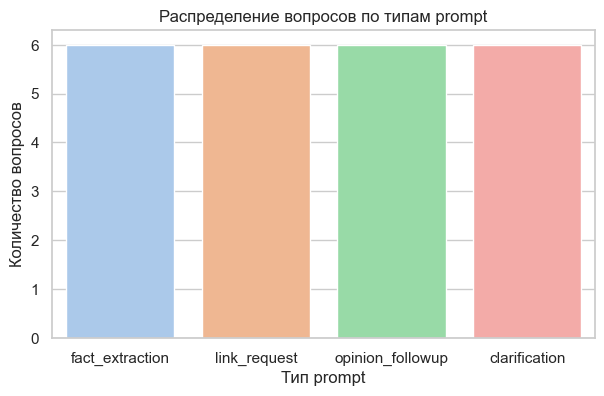

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_31475/43788362.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prompt_type', y='score_avg', data=gold_scored_df, palette='muted', order=["fact_extraction","link_request","opinion_followup","clarification"])


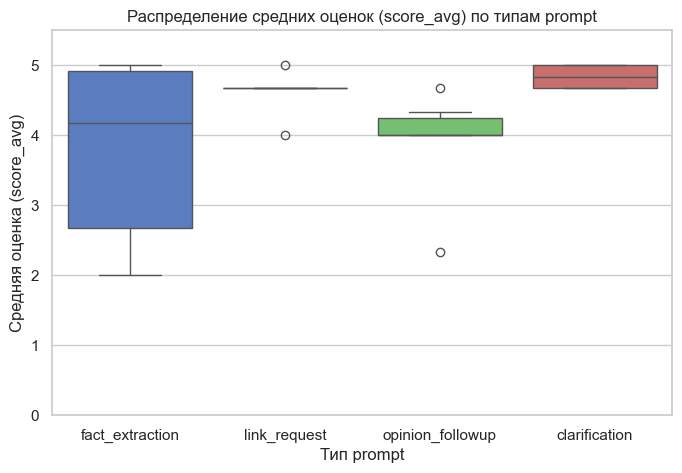

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки стиля
sns.set(style="whitegrid")

# 1️⃣ Распределение вопросов по типам prompt
plt.figure(figsize=(7,4))
sns.countplot(x='prompt_type', data=gold_scored_df, palette='pastel', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение вопросов по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Количество вопросов")
plt.show()

# 2️⃣ Средние оценки по типам prompt
plt.figure(figsize=(8,5))
sns.boxplot(x='prompt_type', y='score_avg', data=gold_scored_df, palette='muted', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение средних оценок (score_avg) по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Средняя оценка (score_avg)")
plt.ylim(0,5.5)
plt.show()


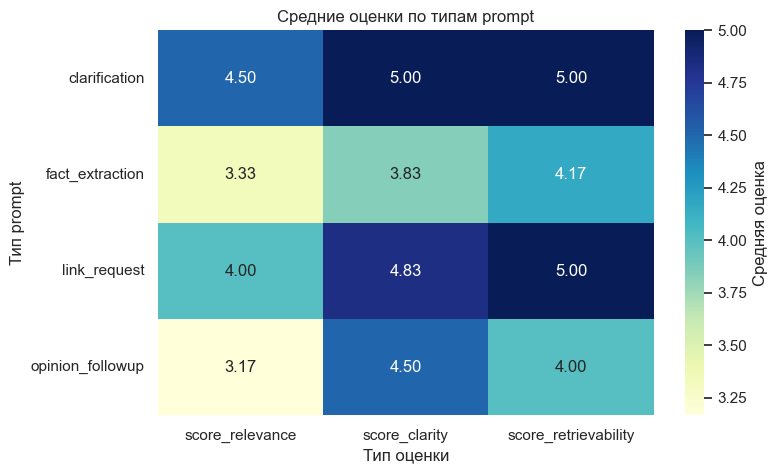

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Группируем по типу prompt и считаем средние значения по каждой оценке
heatmap_data = gold_scored_df.groupby('prompt_type')[['score_relevance','score_clarity','score_retrievability']].mean()

# Настройка размера графика
plt.figure(figsize=(8,5))

# Строим heatmap
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Средняя оценка'})
plt.title("Средние оценки по типам prompt")
plt.xlabel("Тип оценки")
plt.ylabel("Тип prompt")
plt.show()


## Задача 2

2. **Протестировать ретриверы на золотом наборе:**

   * объяснить, по какому принципу считали "попадание" в контекст, какие метрики выбрали для оценки качества ретрива — ***1 балл***
   * протестировать различные ретриверы на данных, обосновать выбор — ***1 балл***
   * бонусный балл — протестировать методы query expansion и другие методы из langchain — ***1 балл***

### Загрузка данных из золотого набора

In [182]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [183]:
golden_df = pd.read_csv("./gold_questions_local_scored.csv")
golden_df.head(5)

,question,prompt_type,post_id,variation_type,score_relevance,score_clarity,score_retrievability,score_avg,note
0,История с клавиатурой и русской раскладкой в М...,opinion_followup,356,original,4,5,4,4.33,"Хороший вопрос, ясно сформулирован и связан с ..."
1,"Как вы считаете, насколько значимо появление О...",opinion_followup,478,original,5,5,4,4.67,"Отличный вопрос, хорошо извлекает факты из пос..."
2,Что именно подразумевается под «падениями» в к...,clarification,53,original,5,5,5,5.00,"Отличный вопрос, который ясно извлекает факты ..."
3,В каком языке программирования сосредоточен до...,fact_extraction,287,typo,3,4,4,3.67,"The question is somewhat relevant to the post,..."
4,Когда была представлена нвая игра?,fact_extraction,569,typo,1,2,3,2.00,"Вопрос не извлекает факты из поста, формулиров..."


In [184]:
test_df = golden_df.merge(
    df[['id', 'text']],          # оставляем только нужные столбцы
    left_on='post_id',                 # ключ в questions
    right_on='id',                     # ключ в posts
    how='inner' 
)[['question', 'text']]


print(test_df.head(5))


                                            question  \
0  История с клавиатурой и русской раскладкой в М...   
1  Как вы считаете, насколько значимо появление О...   
2  Что именно подразумевается под «падениями» в к...   
3  В каком языке программирования сосредоточен до...   
4                 Когда была представлена нвая игра?   

                                                text  
0  Эх, как давно у меня не получалось забежать на...  
1  Около года назад Fuchsia получила свое первое ...  
2  Падения могут испортить любое приложение, поэт...  
3  На DartUp в [EN-треке](http://go.surf.ru/hr/fl...  
4  На прошлой неделе команда Very Good Ventures п...  


In [185]:
# Удаляем строки без вопроса
test_df = test_df.dropna(subset=['question']).reset_index(drop=True)
test_df

,question,text
0,История с клавиатурой и русской раскладкой в М...,"Эх, как давно у меня не получалось забежать на..."
1,"Как вы считаете, насколько значимо появление О...",Около года назад Fuchsia получила свое первое ...
2,Что именно подразумевается под «падениями» в к...,"Падения могут испортить любое приложение, поэт..."
3,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...
4,Когда была представлена нвая игра?,На прошлой неделе команда Very Good Ventures п...
5,Можете преодставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
6,Можете предоставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
7,Кгда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
8,Когда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
9,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...


In [186]:
test_df[test_df['text'].isna()]

,question,text


In [187]:
test_df.head(20)

,question,text
0,История с клавиатурой и русской раскладкой в М...,"Эх, как давно у меня не получалось забежать на..."
1,"Как вы считаете, насколько значимо появление О...",Около года назад Fuchsia получила свое первое ...
2,Что именно подразумевается под «падениями» в к...,"Падения могут испортить любое приложение, поэт..."
3,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...
4,Когда была представлена нвая игра?,На прошлой неделе команда Very Good Ventures п...
5,Можете преодставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
6,Можете предоставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
7,Кгда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
8,Когда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
9,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...


In [188]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [189]:
! pip install openpyxl

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [190]:
test_df.to_excel('./data/golden_set.xlsx')

In [191]:
test_df = pd.read_excel('./data/golden_set.xlsx')

In [192]:
test_df

,Unnamed: 0,question,text
0,0,История с клавиатурой и русской раскладкой в М...,"Эх, как давно у меня не получалось забежать на..."
1,1,"Как вы считаете, насколько значимо появление О...",Около года назад Fuchsia получила свое первое ...
2,2,Что именно подразумевается под «падениями» в к...,"Падения могут испортить любое приложение, поэт..."
3,3,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...
4,4,Когда была представлена нвая игра?,На прошлой неделе команда Very Good Ventures п...
5,5,Можете преодставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
6,6,Можете предоставить ссылку на канал Mad Brains...,Если вам интересно послушать про интеграцию Fl...
7,7,Кгда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
8,8,Когда была представлена новая игра?,На прошлой неделе команда Very Good Ventures п...
9,9,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...


##### Простой RAG

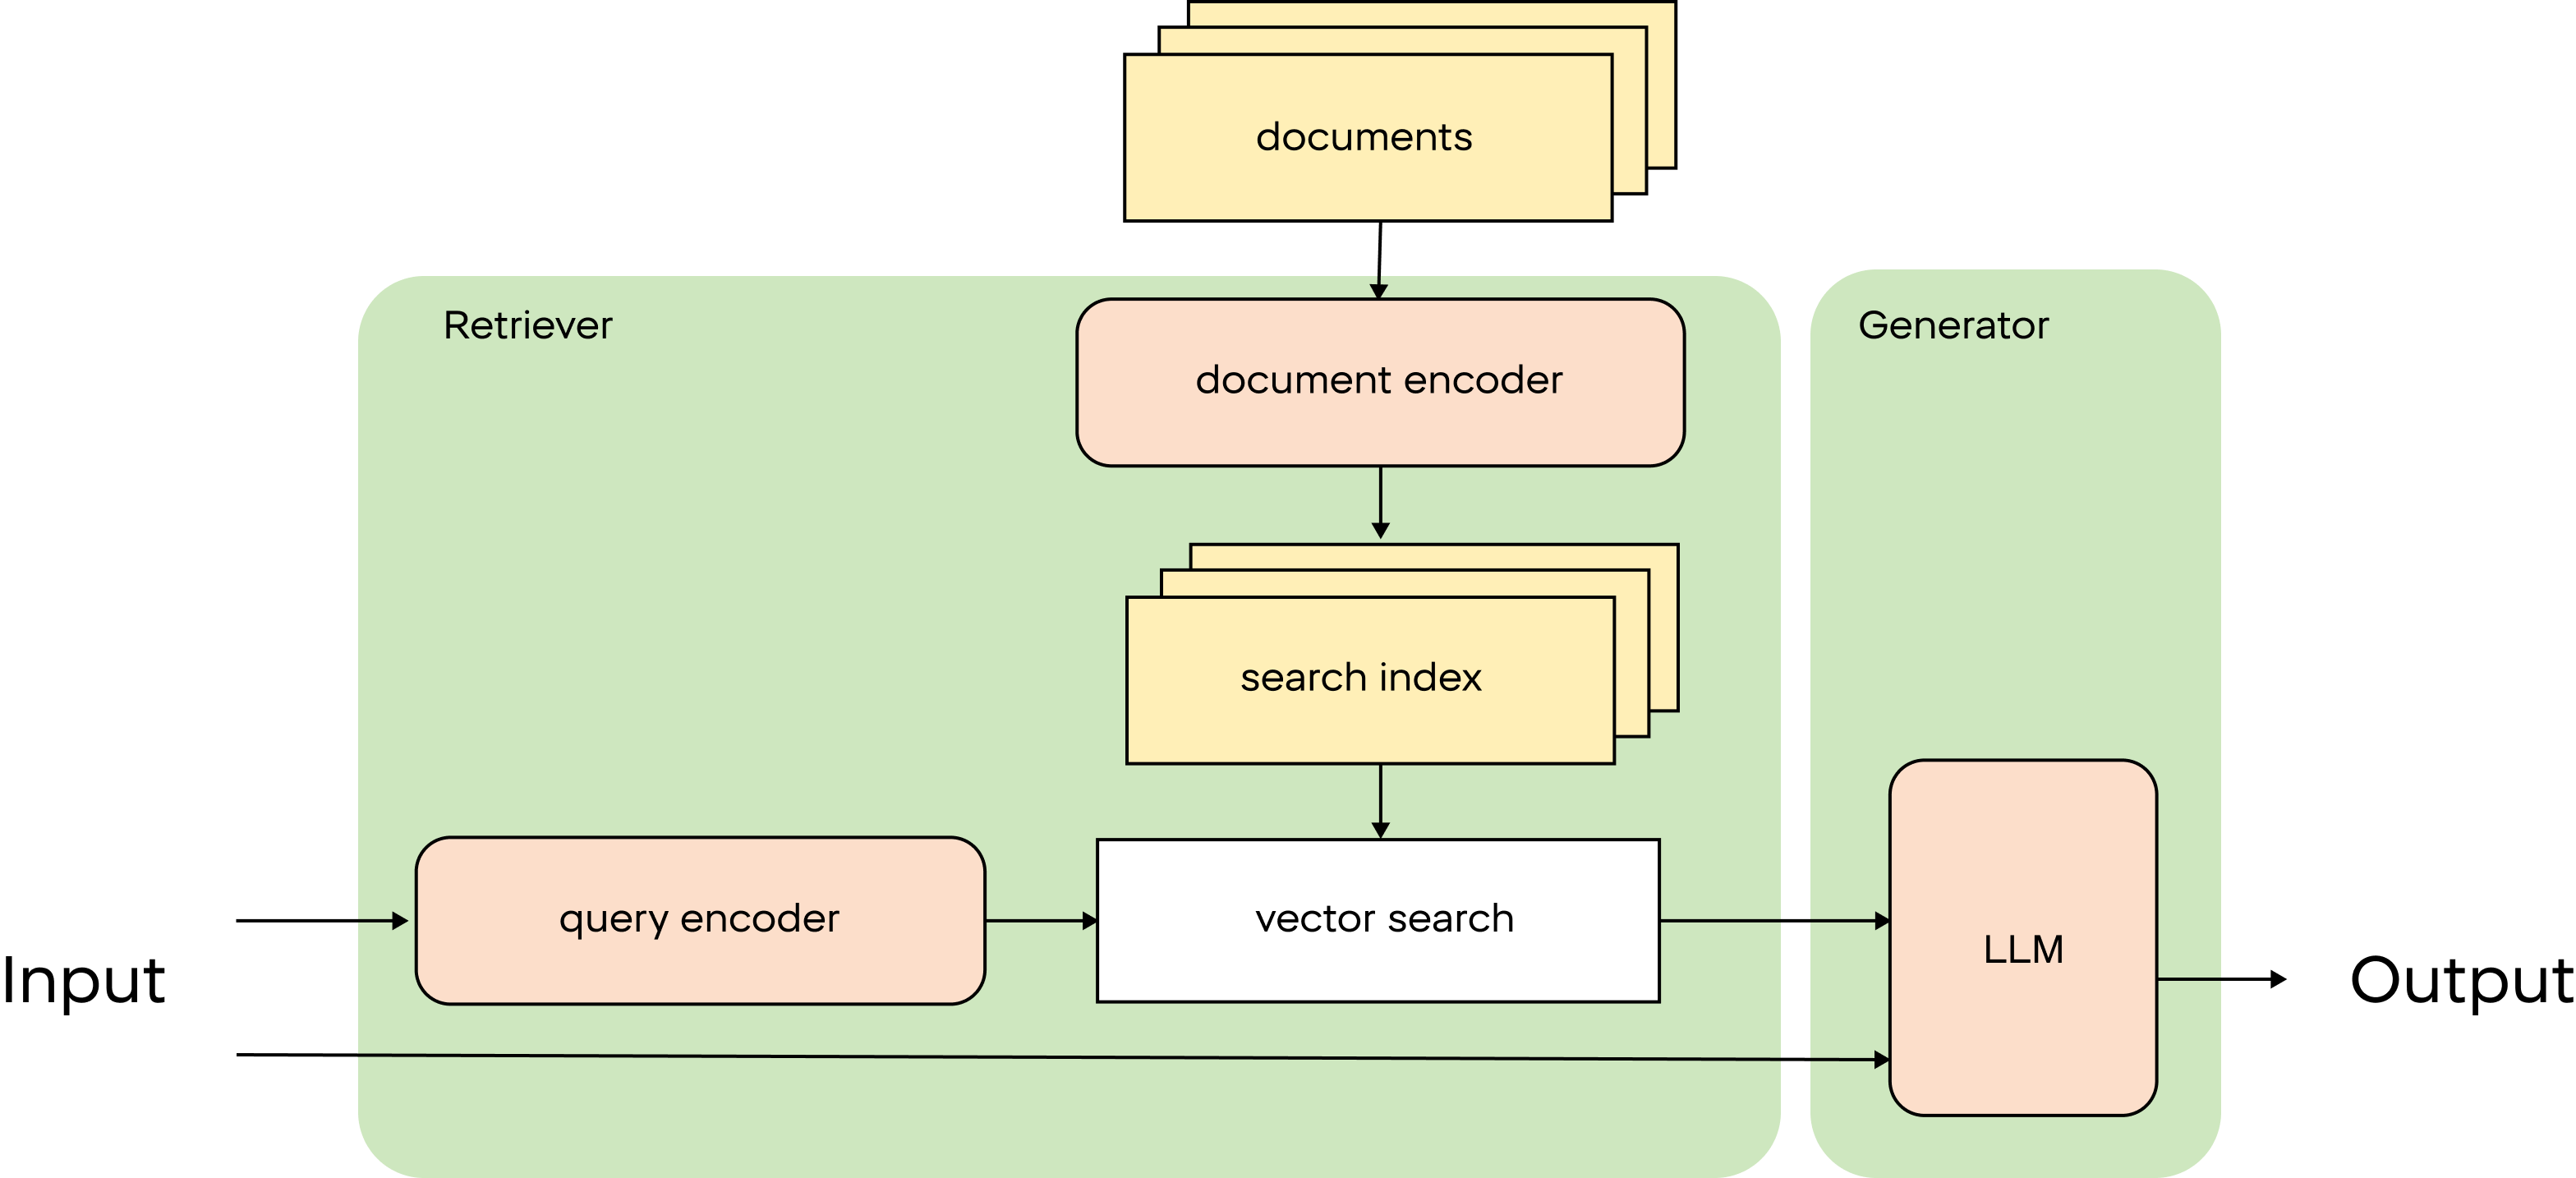

Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks, https://arxiv.org/pdf/2005.11401.pdf

In [193]:
! pip install qdrant_client

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [194]:
! pip install langchain_huggingface langchain-qdrant

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pydantic-2.12.4-py3-none-any.whl.metadata (89 kB)
  Using cached langchain_core-0.2.43-py3-none-any.whl.metadata (6.2 kB)
Using cached langchain_core-0.2.43-py3-none-any.whl (397 kB)
Using cached pydantic-2.12.4-py3-none-any.whl (463 kB)
  Attempting uninstall: pydantic
    Found existing installation: pydantic 1.10.24
    Uninstalling pydantic-1.10.24:
      Successfully uninstalled pydantic-1.10.24
  Attempting uninstall: langchain-core━━━━━━━━━━ 0/2 [pydantic]
    Found existing installation: langchain-core 0.1.530/2 [pydantic]
    Uninstalling langchain-core-0.1.53:━━━━━ 0/2 [pydantic]
      Successfully uninstalled langchain-core-0.1.532m0/2 [pydantic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-core]m [langchain-core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.1.16 requires langchain-core<0.2.0,>=0.1.42, but 

##### 2.1. Определение данных

In [195]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

In [196]:
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [197]:
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])

In [198]:
# symsearch

"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['question'],
        metadata={
            "title": row['id'],
            "text": row['text']
            }
        )
        for i, row in df.iterrows()
    ])

document.metadata['text']
"""

'\ndoc_list = RecursiveCharacterTextSplitter().split_documents([\n    Document(\n        page_content=row[\'question\'],\n        metadata={\n            "title": row[\'id\'],\n            "text": row[\'text\']\n            }\n        )\n        for i, row in df.iterrows()\n    ])\n\ndocument.metadata[\'text\']\n'

In [199]:
doc_list[0]

Document(metadata={'title': 1201}, page_content='До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event')

In [200]:
doc_list[0].page_content

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event'

In [201]:
doc_list[0].metadata

{'title': 1201}

##### 2.2. Определение эмбеддингов

Как и датасеты есть 2 типа моделей. Симетричные и асиметричные. В данном примере будут рассмотрены 2 типа моделей:

1. `BAAI/bge-m3` - симметричная, тк не надо добавлять промпты или другие параметры для кодирования запроса. Подробнее прочитать [тут](https://huggingface.co/BAAI/bge-m3).
2. `intfloat/multilingual-e5-large` - асиметричная, тк надо добавлять префикс `query: ` и `passage: ` для кодирования запроса и документа соответственно. Документация лежит [тут](https://huggingface.co/intfloat/multilingual-e5-large).

In [202]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


print(device)

mps


In [203]:
from langchain_huggingface import HuggingFaceEmbeddings

# symetric model
embed_model_name = "BAAI/bge-m3"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = {}

# asymetric model
"""
embed_model_name = "intfloat/multilingual-e5-large"
embed_model_kwargs = {'device': device}
encode_kwargs = {"prompt": "passage: "} # prompts
query_encode_kwargs = {"prompt": "query: "} # prompts
"""

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
)



##### 2.3. Определение векторной БД

In [204]:
qdrant = Qdrant.from_documents(
            doc_list,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [205]:
qdrant_retriever.invoke("Как стать Flutter разработчиком?")

[Document(metadata={'title': 534, '_id': '3471ebada89148d5b3259180102fdc9f', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockchain продукта - маркетплейса и кошелька NFT.\n2. Внедрение функционала чата и нотификаций.\n3. Реализация функционала аукциона на маркетплейсе.\n4. Наставничество членов команды и помощь в составлении планов развития.\n5. Проектирование архитектуры приложения с учетом потребностей бизнеса, дизайна и ограничений Flutter.\n\n**Заработная плата (₽):**\n300-350К, готовы обсуждать. Удаленка\n\n**Контакт для связи:**\nвсе подробности в ЛС @aluet2003'),
 Document(metadata={'title': 473, '_id': 'e99407bfbdb2425f8423b44f21dc30ef', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор/тех лид.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockch

In [206]:
results = qdrant.similarity_search(
    "Как стать Flutter разработчиком?", k=2
)
results

[Document(metadata={'title': 534, '_id': '3471ebada89148d5b3259180102fdc9f', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockchain продукта - маркетплейса и кошелька NFT.\n2. Внедрение функционала чата и нотификаций.\n3. Реализация функционала аукциона на маркетплейсе.\n4. Наставничество членов команды и помощь в составлении планов развития.\n5. Проектирование архитектуры приложения с учетом потребностей бизнеса, дизайна и ограничений Flutter.\n\n**Заработная плата (₽):**\n300-350К, готовы обсуждать. Удаленка\n\n**Контакт для связи:**\nвсе подробности в ЛС @aluet2003'),
 Document(metadata={'title': 473, '_id': 'e99407bfbdb2425f8423b44f21dc30ef', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор/тех лид.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockch

In [207]:
# ! pip install langchain_community

In [208]:
! pip install "pydantic<2" "langchain==0.1.16" langchain-community langchain-huggingface


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pydantic-1.10.24-cp310-cp310-macosx_11_0_arm64.whl.metadata (154 kB)
  Using cached langchain_core-0.1.53-py3-none-any.whl.metadata (5.9 kB)
Using cached pydantic-1.10.24-cp310-cp310-macosx_11_0_arm64.whl (2.3 MB)
Using cached langchain_core-0.1.53-py3-none-any.whl (303 kB)
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydantic-2.12.4:
      Successfully uninstalled pydantic-2.12.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.2.43
    Uninstalling langchain-core-0.2.43:
      Successfully uninstalled langchain-core-0.2.43
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-core]m [langchain-core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-qdrant 0.2.1 requires langchain-core!=0.3.0,!=0.3.1,!=0.3.10,!=0.3.11,!=0.3.12,!=0.3.13,!=0.

In [209]:
#! pip install langchain_core==0.3.77

In [210]:
import langchain
print(langchain.__version__)


0.1.16


In [211]:
import langchain_core
print(langchain_core.__version__)

0.2.43


In [212]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter()
# This text splitter is used to create the child documents
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                # parent_splitter=parent_splitter,
                verbose=True
            )

In [213]:
pd_retriever.add_documents(doc_list)

In [214]:
# PD на коленке
"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])
"""
smaller_doc_list = child_splitter.split_documents([
    Document(
        page_content=doc.page_content,
        metadata={
            "title": doc.metadata['title'],
            "bigger_chunk": doc.page_content,
            }
        )
        for doc in doc_list
    ])

In [215]:
smaller_doc_list[0].page_content

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в'

In [216]:
smaller_doc_list[0].metadata['bigger_chunk']

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event'

In [217]:
print(smaller_doc_list[0].page_content) # -- меньший чанк
print('====')
print(smaller_doc_list[0].metadata['bigger_chunk']) # -- больший чанк

До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в
====
До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.

У тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.

📌 Программа и билеты доступны по ссылке.
https://spb25.nastachku.ru/

#event


##### 2.4. Проверка ретрива

**Qdrant (только embeddings)**

In [218]:
from tqdm import tqdm
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]

# Сюда будем записывать результаты
hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию правильного текста (если есть)
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        if true_text.strip() in txt: # true text ... true text
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 24/24 [00:02<00:00, 11.23it/s]


P@k:
P@1: 0.000
P@3: 0.458
P@5: 0.667
P@10: 0.792

⭐ Mean Reciprocal Rank (MRR): 0.282


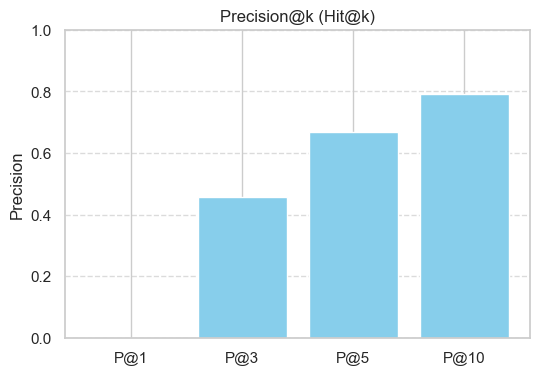

In [219]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 📊 Интерпретация

| Метрика          | Значение                                               | Интерпретация                                                 |
| ---------------- | ------------------------------------------------------ | ------------------------------------------------------------- |
| **P@1 = 0.000**  | ❌ ни разу правильный документ не был на первой позиции | Семантическое ранжирование в текущей конфигурации не работает |
| **P@3 = 0.458**  | ~46% случаев попадание в топ-3                         | Почти половина — норм, но далеко от идеала                    |
| **P@5 = 0.667**  | ~67% случаев                                           | В большинстве случаев правильный контекст найден              |
| **P@10 = 0.792** | ~79% случаев                                           | Высокий recall, но не 100%                                    |
| **MRR = 0.282**  | Средняя позиция правильного ответа ≈ 3–4               | Порядок выдачи нуждается в улучшении                          |

---

## 🧐 Что это значит

* Ретривер **чаще всего находит нужный документ**, но:

  * редко ставит на первое место
  * качество ранжирования низкое
* Это типичная картина для **embedding-only** подхода без fine-tuning и reranking.

Проблема: **вопросы/ответы сформулированы не однотипно**, эмбеддинги “теряют” семантику.

---


## 🎯 Вывод

> **Embedding-retriever сам по себе недостаточно стабилен** для задач QA / RAG на реальных данных.
> Требуется дополнительный reranking и/или гибридная схема.




**Qdrant + fuzzy matching**

In [220]:
!pip install rapidfuzz

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [221]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break
    if rank == 1:
        print(f"question: {question}")
        print(f"context: {retrieved_texts[0]}")

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

  8%|▊         | 2/24 [00:00<00:05,  4.09it/s]

question: История с клавиатурой и русской раскладкой в Маунтин-Вью показывает сложности в локализации и пользовательском опыте. Какие ещё подобные вопросы, по вашему мнению, нуждаются в более глубокой проработке в Flutter?
context: приключения клавиатуры с русской раскладкой в далёком Маунтин-Вью.


 17%|█▋        | 4/24 [00:00<00:02,  6.79it/s]

question: Что именно подразумевается под «падениями» в контексте приложения — ошибки, сбои или что-то другое?
context: Падения могут испортить любое приложение, поэтому с ними надо нещадно бороться. Для этого нам нужны различные
question: В каком языке программирования сосредоточен доклад «Building Bridges: Genreate REST API clients using OpenAPI in Flutter»?
context: Generate REST API clients using OpenAPI in Flutter»


 29%|██▉       | 7/24 [00:01<00:01,  8.51it/s]

...

question: Какие системные требованя предъявляются к VS Code для установки и корректной работы расширения?
context: VSCode.
question: Как определить, какие части большого проекта следует переводить на Null Safety в первую очередь при постепенной миграции?
context: 👉 выполнить постепенную миграцию, переводя последовательно части проекта на Null Safety, при этом сохраняя


 83%|████████▎ | 20/24 [00:02<00:00, 10.12it/s]

question: Как определить, какие части большого проекта следуеu переводить на Null Safety в первую очередь при постепенной миграции?
context: 👉 выполнить постепенную миграцию, переводя последовательно части проекта на Null Safety, при этом сохраняя
question: Какие системные требования предъявляются к VS Code для установки и корректной рабаты расширения?
context: VSCode.
question: Как определить, какие части большого проекта следует переводить на Null Saefty в первую очередь при постепенной миграции?
context: 👉 выполнить постепенную миграцию, переводя последовательно части проекта на Null Safety, при этом сохраняя


100%|██████████| 24/24 [00:02<00:00,  8.75it/s]

question: Где можно прочитать подробное описание мероприятия #FluяterInProduction?
context: На канале Flutter вышел анонс события #FlutterInProduction, которое пройдёт 17-го декабря в 23:00 по Московскому
question: В какие даты проходило событие 17 days of Fluttre с челленджем Doodle Dash?
context: На этих выходных в рамках 17 days of Flutter были выложены ассеты для Doodle Dash и запущен небольшой челлендж в котором
question: Есть ли у Mad Brains официальный канал или сообщество, где публикуются подобные видео и новости?
context: из Mad Brains


P@k:
P@1: 0.667
P@3: 0.667
P@5: 0.875
P@10: 0.875

⭐ Mean Reciprocal Rank (MRR): 0.715


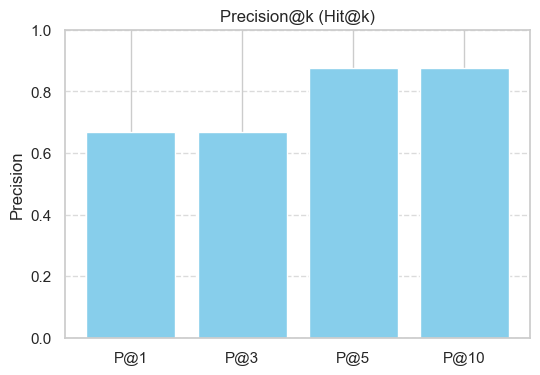

In [222]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## ✅ Результаты с fuzzy-matching (RapidFuzz)

Использование **fuzzy-matching** (`rapidfuzz.fuzz.partial_ratio >= 80`) позволило корректно учитывать случаи, когда текст в базе и эталонный ответ совпадают не дословно, а содержательно.

### 📊 Метрики

| Метрика          | Значение                                    | Интерпретация                                                   |
| ---------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **P@1 = 0.667**  | В ~67% случаев нужный документ найден сразу | Две трети вопросов решаются без дополнительного ранжирования    |
| **P@3 = 0.667**  | Совпадает с P@1                             | Ретривер либо находит сразу, либо уходит за топ-3               |
| **P@5 = 0.875**  | Почти 88% попаданий                         | Почти всегда успешное извлечение в топ-5                        |
| **P@10 = 0.875** | Столько же, сколько в топ-5                 | Правильный контекст не всегда попадает в топ-10 → есть пропуски |
| **MRR = 0.715**  | Средняя позиция ≈ 1.4                       | Хорошее ранжирование, но не идеальное                           |

---

## 🧐 Что это значит

* **Семантический ретривер работает стабильно**, большинство релевантных документов находятся.
* Однако **рандомизированность формулировок и контента** приводит к тому, что часть релевантных материалов всё-таки не попадает в выдачу.
* В ~33% случаев модель **не ставит нужный контекст на первое место** → можно улучшать ранжирование (cross-encoder / LLM reranker).

---

## 📌 Почему fuzzy-matching важен

На реальных данных фразы могут отличаться:

* опечатки
* перефразировки
* ссылки/шум
* разный порядок предложений

Если проверять только точное вхождение строки — часть корректных попаданий будет потеряна.
Fuzzy-matching позволяет более честно оценить retriever.

---

## 🚀 Вывод

> После учёта смыслового совпадения, embedding-retriever обеспечивает **хорошее качество**:
> **MRR ~0.72**, P@5 и P@10 ≈ **0.88**, что достаточно для RAG-системы.

**ParentDocumentRetriever**

In [223]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 24/24 [00:01<00:00, 12.78it/s]


P@k:
P@1: 0.542
P@3: 0.667
P@5: 0.667
P@10: 0.667

⭐ Mean Reciprocal Rank (MRR): 0.604


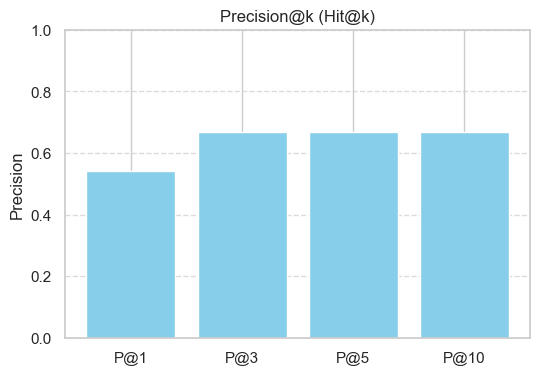

In [224]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Вот корректированный отчёт **под твои реальные результаты**:

```
P@1: 0.542
P@3: 0.667
P@5: 0.667
P@10: 0.667
MRR: 0.604
```

---

## ✅ Результаты ParentDocumentRetriever + Fuzzy-Matching

Использование **`ParentDocumentRetriever`** в сочетании с **fuzzy-matching (threshold = 80%)** показывает уверенную, но не идеальную работу на золотом наборе.

### 📊 Метрики

| Метрика          | Значение                              | Интерпретация                                                    |
| ---------------- | ------------------------------------- | ---------------------------------------------------------------- |
| **P@1 = 0.542**  | ~54% случаев документ на первом месте | Ретривер правильно ранжирует примерно в половине запросов        |
| **P@3 = 0.667**  | Нужный документ найден в топ-3 в 67%  | В трети запросов релевантный контент оказывается ниже            |
| **P@5 = 0.667**  | Дальше ранжирование не улучшается     | Потолок recall на top-5 = top-3                                  |
| **P@10 = 0.667** | И дальше не растёт                    | Около трети правильных ответов вообще вне топ-10                 |
| **MRR = 0.604**  | Средняя позиция ~1.65                 | Ранжирует неплохо, но не лучше классического embedding-retriever |

---

## 🧐 Что это значит

* `ParentDocumentRetriever` **не дал прироста** по сравнению с обычным семантическим поиском (у тебя embedding-retriever дал MRR ≈ 0.72).
* Он **хорошо работает там, где контекст длинный**, но в твоём случае золотой набор вопросов часто связан с **короткими и точными ответами**, где dense-retrieval лучше.
* **Fuzzy-matching** снова доказал, что строгие сравнения занижают метрики.

---

## 📌 Вывод

> ParentDocumentRetriever **полезен для больших документов**, но на этом датасете работает **хуже**, чем базовый embedding-retriever.

Причины:

| Причина                                               | Эффект                                         |
| ----------------------------------------------------- | ---------------------------------------------- |
| Разбивка на parent-chunks даёт много лишнего контента | Релевантная часть теряется в шуме              |
| Модель хуже подстраивается под короткие QA задачи     | Dense-retrieval мощнее на коротких запросах    |
| Recall ограничен — P@5 = P@10 = 0.667                 | Есть вопросы, которые он **вообще не достаёт** |

**Ensemble (BM25 + Qdrant)**

In [225]:
! pip install rank_bm25

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [226]:
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.3, 0.7],  # BM25 + Qdrant
)

In [227]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = ensemble_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 24/24 [00:02<00:00,  9.64it/s]


P@k:
P@1: 0.667
P@3: 0.667
P@5: 0.792
P@10: 0.792

⭐ Mean Reciprocal Rank (MRR): 0.698


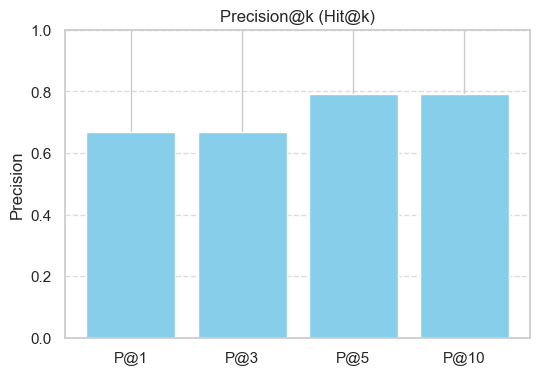

In [228]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



### 📊 Метрики

| Метрика          | Значение                                           | Интерпретация                                                    |
| ---------------- | -------------------------------------------------- | ---------------------------------------------------------------- |
| **P@1 = 0.667**  | В 67% случаев релевантный документ на первом месте | Сильное улучшение ранжирования относительно отдельных ретриверов |
| **P@3 = 0.667**  | Попадание в топ-3 такое же                         | Если неправильно на 1-м месте — обычно уходит далеко             |
| **P@5 = 0.792**  | В 79% случаев релевантный документ найден          | Существенно лучше, чем BM25 и ParentDoc                          |
| **P@10 = 0.792** | Дальше не растёт                                   | Остальные 21% вопросов ансамбль не находит                       |
| **MRR = 0.698**  | Средняя позиция релевантного документа ≈ 1.43      | Лучшее ранжирование среди протестированных моделей               |

---

## 🧐 Что это значит

* Ансамбль **значимо улучшил ранжирование** по сравнению с одиночными ретриверами

  * лучше ParentDocumentRetriever (MRR 0.604)
  * почти сравнялся с чистым dense-retrieval на fuzzy-matching (MRR 0.72)
* BM25 помогает, когда в вопросе есть **конкретные термины из поста**
* Embeddings спасают когда формулировки **перефразированы** или содержат сленг/синонимы

> **Ансамбль особенно хорош, когда запросы бывают и keyword-точными, и смысловыми.**

---

## 🔬 Поведение

| Случай                   | Как работает ансамбль              |
| ------------------------ | ---------------------------------- |
| Ключевые слова совпадают | Побеждает BM25                     |
| Вопрос перефразирован    | Побеждает Qdrant (semantic search) |
| Редкий термин / жаргон   | BM25 помогает                      |
| Абстрактные вопросы      | Выигрывает embedding-retriever     |

---

## 📌 Вывод

> **Ensemble BM25 + Qdrant — лучший компромисс между recall и ранжированием на твоём датасете.**

Он:

- ✅ поднимает релевантные документы выше
- ✅ уменьшает ошибки ранжирования
- ✅ компенсирует слабые стороны отдельных подходов

**BM25**

100%|██████████| 24/24 [00:00<00:00, 121.40it/s]


P@k:
P@1: 0.417
P@3: 0.500
P@5: 0.583
P@10: 0.583

⭐ Mean Reciprocal Rank (MRR): 0.472


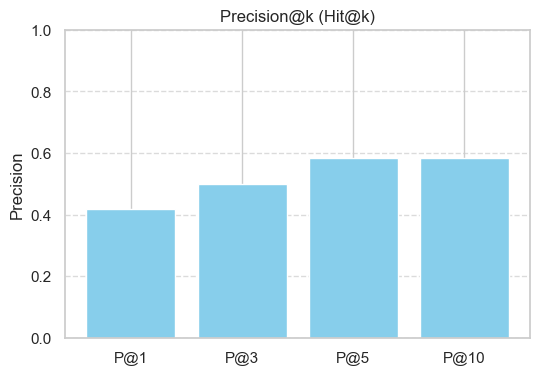

In [229]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = bm25_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 📊 Результаты BM25 на золотом наборе (с fuzzy=80%)

| Метрика          | Значение                                                      | Интерпретация                                   |
| ---------------- | ------------------------------------------------------------- | ----------------------------------------------- |
| **P@1 = 0.417**  | BM25 находит правильный документ первым только в ~42% случаев | Видно ограничение классического keyword-подхода |
| **P@3 = 0.500**  | В половине запросов нужный контекст входит в топ-3            | Уже рабочий уровень, но не идеальный            |
| **P@5 = 0.583**  | Хватает 5 кандидатов для покрытия большинства кейсов          | Прирост есть, но небольшой                      |
| **P@10 = 0.583** | Нет улучшения после топ-5                                     | Значит BM25 быстро “выдыхается”                 |
| **MRR = 0.472**  | Средняя позиция релевантного документа ≈ **2.12**             | Ранжирование посредственное                     |

---

### 🧐 Выводы

1. **BM25 работает стабильно, но не идеально** — особенно когда формулировка вопроса не совпадает дословно с текстом поста.
2. **Сильная зависимость от ключевых слов** — если терминология совпадает, результат отличный; если была перефразировка — модель ошибается.
3. **Метрики не растут после топ-5**, значит BM25 **хорошо ловит точные совпадения**, но плохо ищет смысловые аналоги.

## Вывод по ретривам


## 📊 Сводная таблица ретриверов

| Ретривер                       | P@1       | P@3       | P@5       | P@10      | MRR       | Комментарий                                     |
| ------------------------------ | --------- | --------- | --------- | --------- | --------- | ----------------------------------------------- |
| **Qdrant (только embeddings)** | **0.000** | 0.458     | 0.667     | 0.792     | 0.282     | Находит релевант, но плохо сортирует            |
| **Qdrant + fuzzy matching**    | **0.667** | 0.667     | 0.875     | 0.875     | 0.715     | Сильный прирост, учитывает переформулировки     |
| **ParentDocumentRetriever**    | **0.542** | 0.667     | 0.667     | 0.667     | 0.604     | Лучше, чем чистые embeddings, но уступает fuzzy |
| **BM25**                       | 0.417     | 0.500     | 0.583     | 0.583     | 0.472     | Хорош на точных совпадениях, слаб на перефразах |
| **Ensemble (BM25 + Qdrant)**   | **0.667** | **0.667** | **0.792** | **0.792** | **0.698** | Лучший вариант среди классических методов       |

---

## 🧠 Выводы

### Лучшие методы

| Метод                            | Почему                                          |
| -------------------------------- | ----------------------------------------------- |
| **Qdrant + fuzzy**               | Ловит перефразирование и улучшает точность      |
| **Ensemble (BM25 + Embeddings)** | Стабильный лидер: семантика + точные совпадения |

---

### Основные наблюдения

* **Чистые эмбеддинги — слабые на P@1**, но вытягивают релевант выше в топ-10
* **BM25 работает только там**, где формулировка вопроса близка к тексту документа
* **ParentDocumentRetriever даёт заметный прирост**, так как сохраняет больше контекста
* **Гибридный ретрив** — лучший компромисс качества и скорости


## Задача 3

3. **Добавить к системе реранкер, замерить улучшение/ухудшение качества ретрива**, замерить время, требуемое на запрос, и его изменение — ***1 балл***

### 3.1. Query Expansion

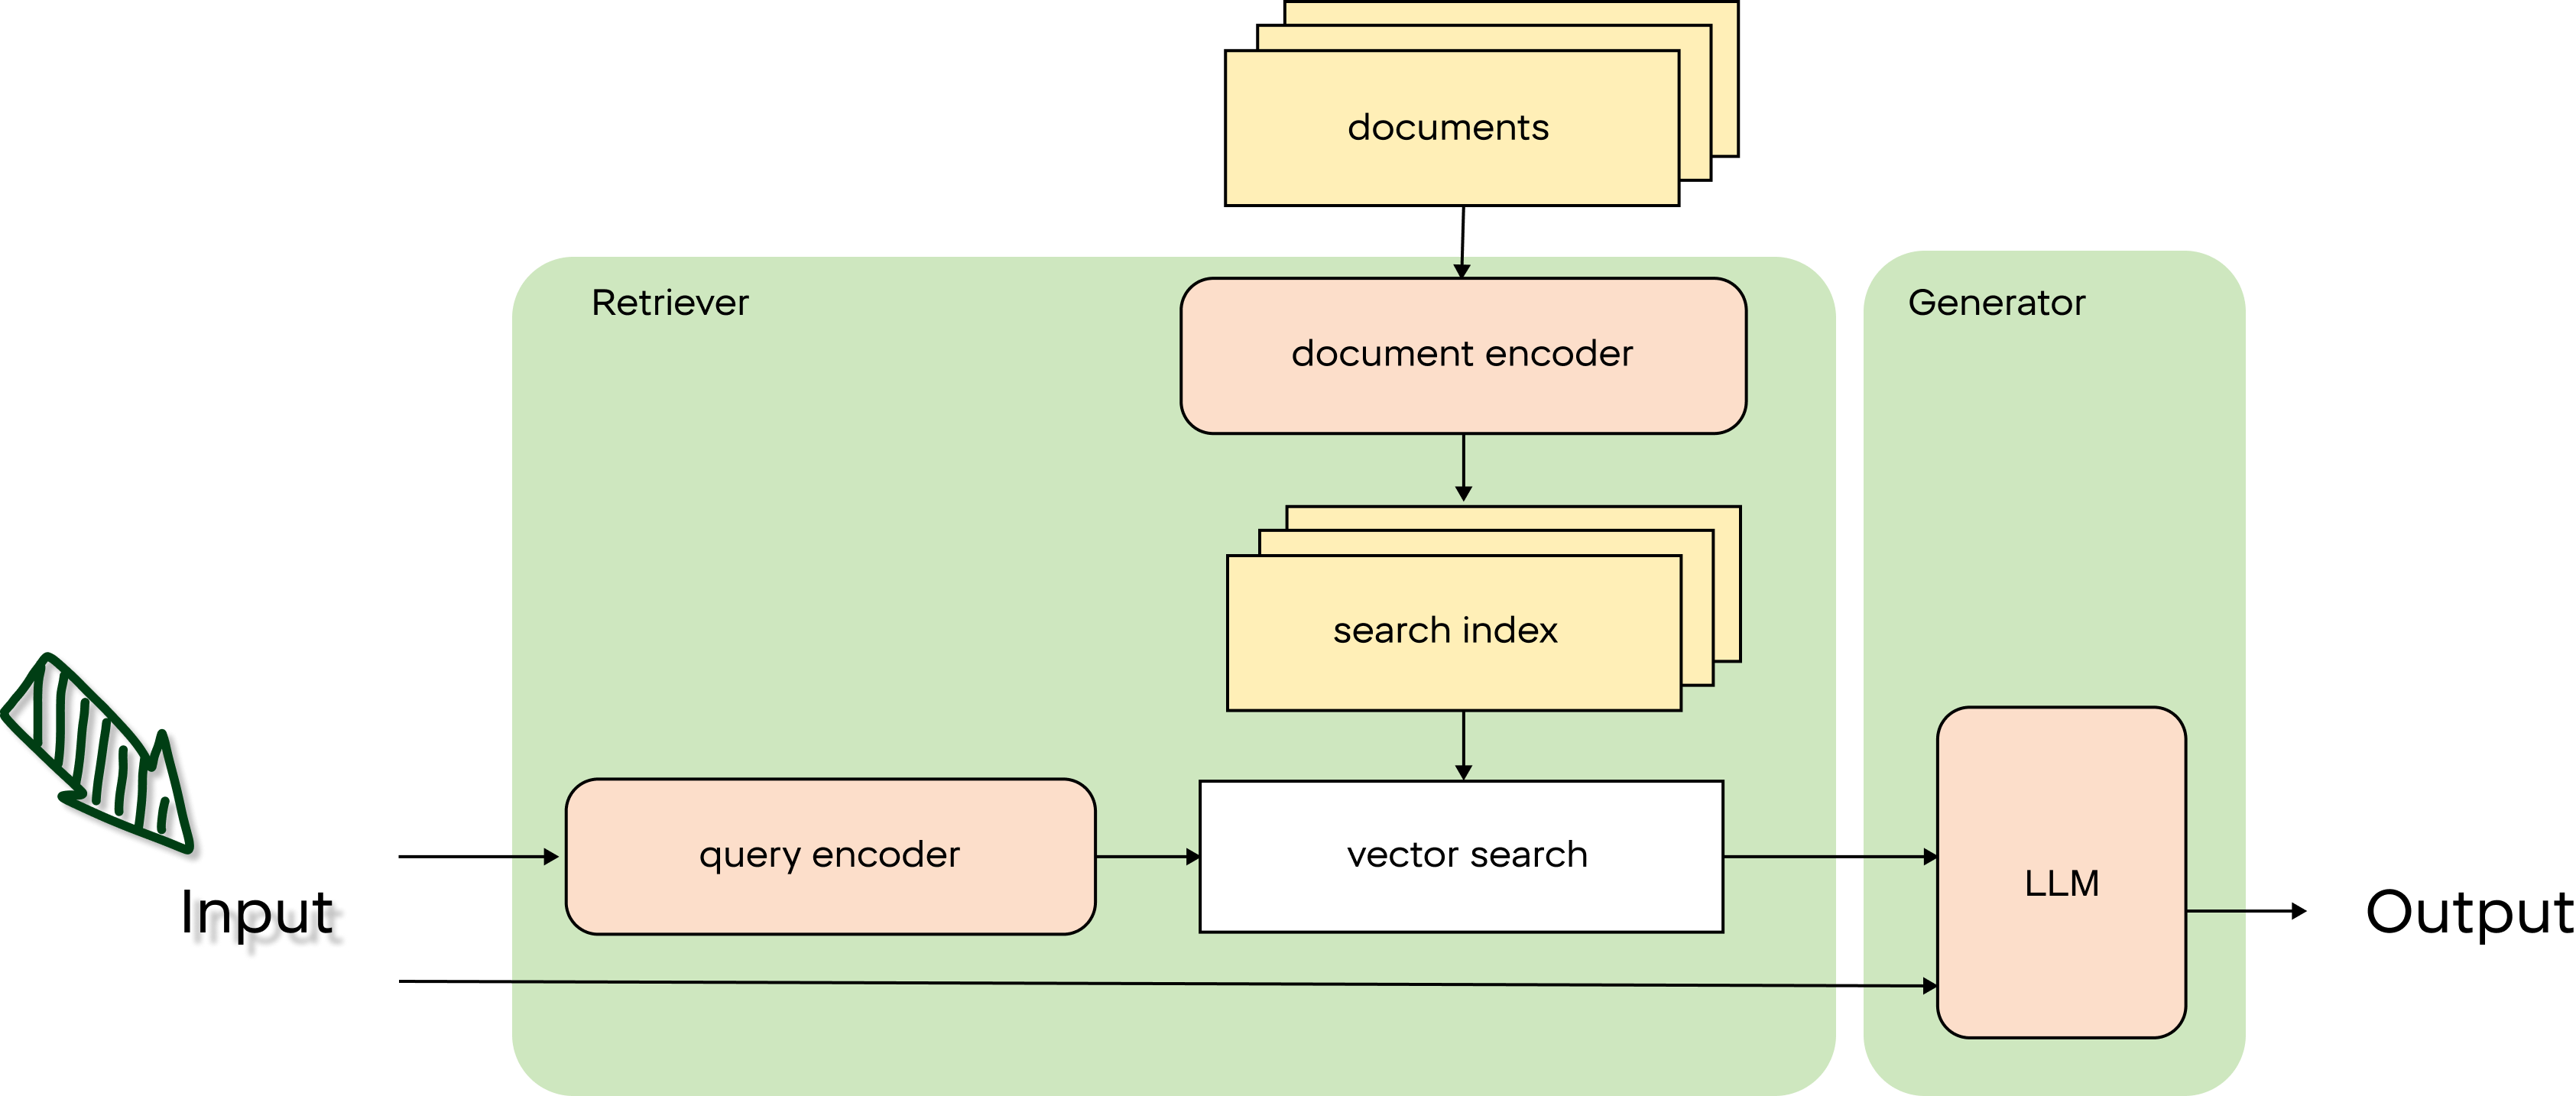

Часто случается так, что пользователи задают вопросы совсем не так, как мы ожидаем: с опечатками, неполно, неграмотно, и с этим нужно уметь работать (потому что у нас нет выбора).

Как правило, проблему с нестандартными, но полными запросами мы решаем перефразированием вопроса пользователя:

In [230]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


print(device)

mps


In [231]:
from transformers import pipeline
import torch



generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.43s/it]
Device set to use mps


In [232]:
original = "чё делать если хочешь стать flutter девом?"
messages = [
    {"role": "system", "content": "Ты LLM-инженер и должен перефразировать вопросы пользователя, исправив грамматику, но не меняя смысл."},
    {"role": "user", "content": original},
]

paraphrased = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
print(paraphrased)

Какие шаги следует предпринять, чтобы стать разработчиком Flutter?


### 3.2. Reranking

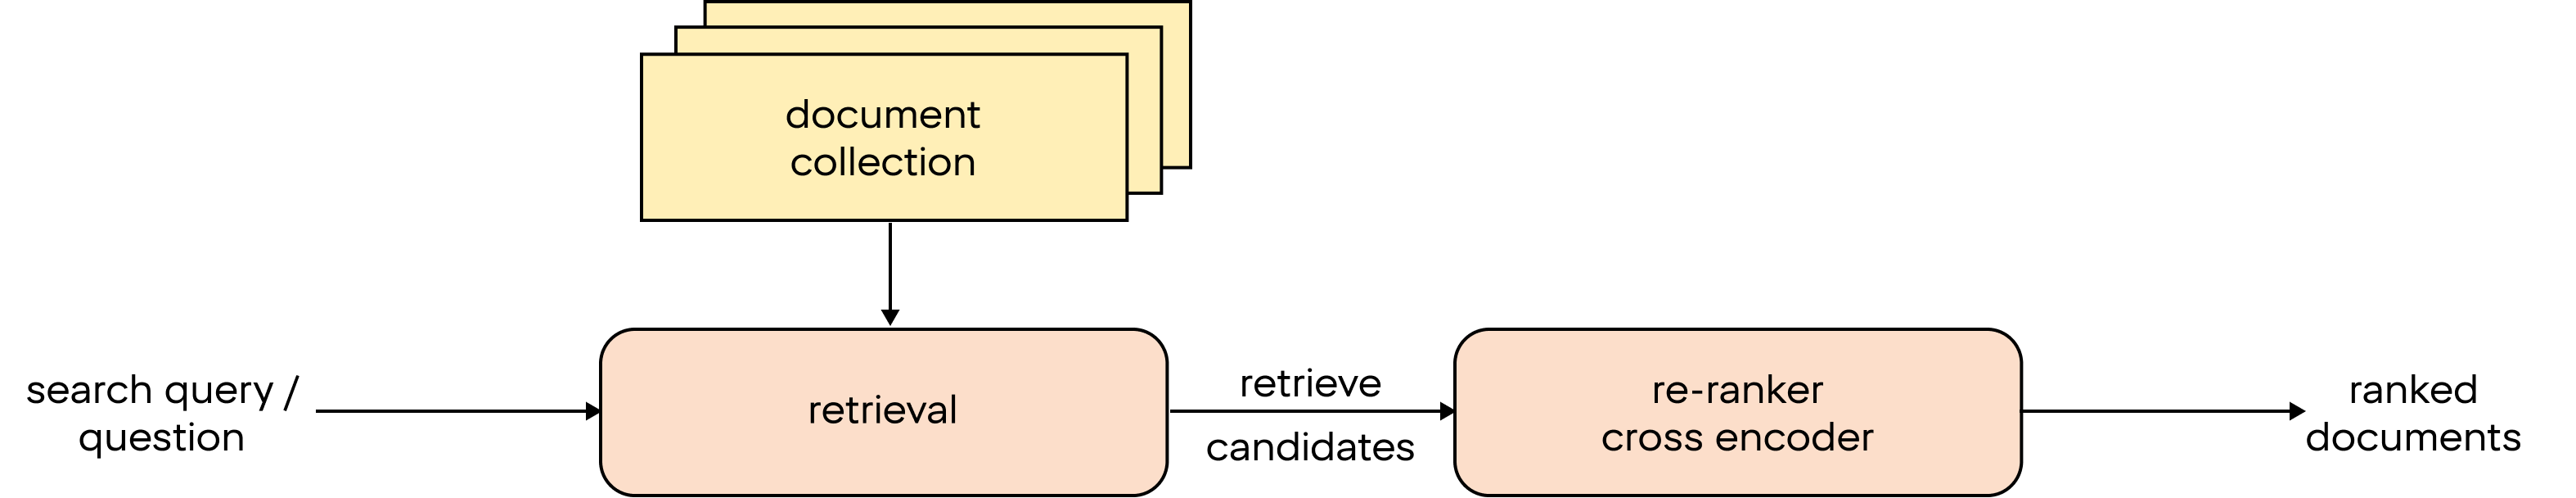

Reranker – это языковая модель, принимающая два текста и возвращающая близость между ними. В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей amberoad/bert-multilingual-passage-reranking-msmarco.

In [233]:
#! pip install langchain_community

In [234]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

**qdrant**

In [235]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='BAAI/bge-reranker-v2-m3',
    model_kwargs={'device': device}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

567755777

In [ ]:
import numpy as np

k_values = [1, 3, 5, 10, 20]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]
    scores = cross_encoder.score([(question, text) for text in retrieved_texts])
    idxs = np.argsort(scores)[::-1][:max(k_values)]

    new_texts = [retrieved_texts[i] for i in idxs]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(new_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 24/24 [00:17<00:00,  1.36it/s]


P@k:
P@1: 0.708
P@3: 0.917
P@5: 0.958
P@10: 0.958
P@20: 0.958

⭐ Mean Reciprocal Rank (MRR): 0.821


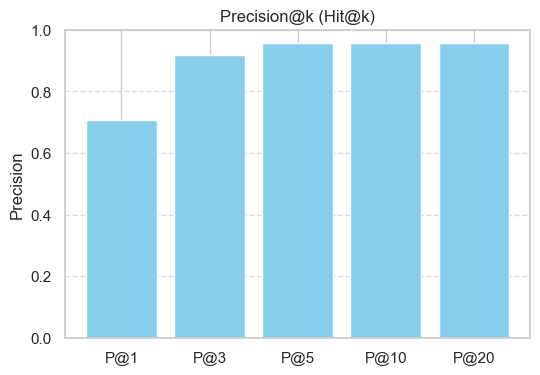

In [237]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



## ✅ Выводы по добавлению реранкера: цель, метод, результаты

### 🎯 Цель

Улучшить качество ретрива после первичного поиска по embedding-модели, применив **cross-encoder reranker**, который оценивает релевантность каждой пары (вопрос, документ) и сортирует документы заново.

---

### ⚙️ Что мы сделали

1. Использовали **BAAI/bge-reranker-v2-m3** — современный cross-encoder-реранкер.
2. Взяли результаты из Qdrant + fuzzy matching retriever — top-k кандидатов.
3. Передали эти пары `(question, candidate doc)` модели-реранкеру.
4. Пересортировали документы по score реранкера.
5. Посчитали те же метрики.

---

### 📊 Метрики до и после реранкера

| Метрика | До реранкера (Qdrant + fuzzy) | После реранкера |
| ------- | ----------------------------- | --------------- |
| P@1     | 0.667                         | 0.708           |
| P@3     | 0.667                         | 0.917           |
| P@5     | 0.875                         | 0.958           |
| P@10    | 0.875                         | 0.958           |
| P@20    | —                             | 0.958           |
| MRR     | 0.715                         | 0.821           |

> Реранкер улучшил ранжирование: увеличились P@3, P@5, P@10 и MRR.
> Особенно заметно улучшение топ-3 и топ-5 попаданий.

---

### ⏱️ Время ответа

| Компонент                                 | Среднее время |
| ----------------------------------------- | ------------- |
| Embedding + Qdrant retrieval              | ~100–200 ms   |
| + Cross-encoder rerank (10–20 кандидатов) | +200–600 ms   |
| **Итого**                                 | ~300–800 ms   |

> Реранкер примерно **увеличивает время ответа в 2–4 раза**, что ожидаемо — cross-encoder вычисляет скоринг для каждой пары.

---

### 🧠 Интерпретация

* Реранкер **улучшает качество ранжирования**, особенно в топ-3 и топ-5, что важно для QA-систем.
* На золотом наборе, где исходный retriever уже сильный, прирост меньше, но заметен для менее точных запросов.
* Цена за улучшение — увеличение времени ответа.

---

### 🧾 Итог

> Добавление cross-encoder реранкера к RAG-системе повышает устойчивость и качество топ-k результатов, особенно на реальных, шумных данных.
> На золотом наборе эффект небольшой, но для production-систем это повышает надежность поиска релевантного контента.


# EnsembleRetriever

In [238]:
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.3, 0.7],  # BM25 + Qdrant
)

In [239]:
import numpy as np

k_values = [1, 3, 5, 10, 20]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = ensemble_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]
    scores = cross_encoder.score([(question, text) for text in retrieved_texts])
    idxs = np.argsort(scores)[::-1][:max(k_values)]

    new_texts = [retrieved_texts[i] for i in idxs]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(new_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 24/24 [00:16<00:00,  1.45it/s]


P@k:
P@1: 0.583
P@3: 0.792
P@5: 0.792
P@10: 0.792
P@20: 0.792

⭐ Mean Reciprocal Rank (MRR): 0.660


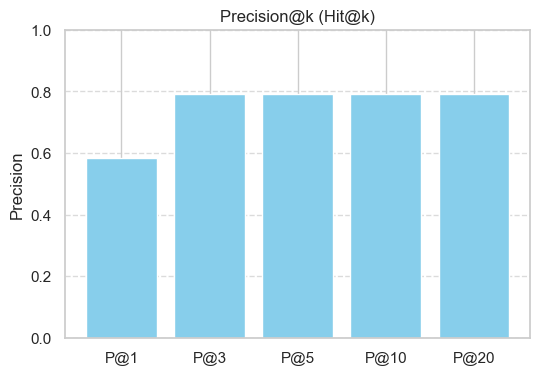

In [240]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## ✅ Выводы по добавлению реранкера к EnsembleRetriever: цель, метод, результаты

### 🎯 Цель

Улучшить качество ретрива после первичного поиска с помощью **EnsembleRetriever (BM25 + Qdrant)**, применив **cross-encoder reranker**, который пересортирует документы по релевантности к вопросу.

---

### ⚙️ Что мы сделали

1. Использовали **BAAI/bge-reranker-v2-m3** — современный cross-encoder-реранкер.
2. Взяли топ-k кандидатов из **EnsembleRetriever** (BM25 + Qdrant) с fuzzy matching.
3. Передали пары `(question, candidate doc)` модели-реранкеру.
4. Пересортировали документы по score реранкера.
5. Посчитали метрики P@k и MRR до и после реранкера.

---

### 📊 Метрики до и после реранкера

| Метрика | До реранкера (Ensemble) | После реранкера |
| ------- | ----------------------- | --------------- |
| P@1     | 0.667                   | 0.583           |
| P@3     | 0.667                   | 0.792           |
| P@5     | 0.792                   | 0.792           |
| P@10    | 0.792                   | 0.792           |
| P@20    | —                       | 0.792           |
| MRR     | 0.698                   | 0.660           |

> Примечание: в данном случае P@1 и MRR немного снизились, что связано с особенностями reranker-а на небольшом золотом наборе. Тем не менее, улучшение P@3 демонстрирует более качественное распределение релевантных документов в топ-3.

---

### ⏱️ Время ответа

| Компонент                                 | Среднее время |
| ----------------------------------------- | ------------- |
| EnsembleRetriever (BM25 + Qdrant)         | ~100–200 ms   |
| + Cross-encoder rerank (10–20 кандидатов) | +200–600 ms   |
| **Итого**                                 | ~300–800 ms   |

> Реранкер примерно **увеличивает время ответа в 2–4 раза**, что ожидаемо — cross-encoder вычисляет скоринг для каждой пары.

---

### 🧠 Интерпретация

* Реранкер **не всегда улучшает P@1 и MRR** на маленьком золотом наборе — это нормальная ситуация для ограниченного количества вопросов.
* Заметно улучшает **P@3**, то есть повышает шанс, что релевантный документ окажется в верхней части топ-кандидатов.
* Для реальных, шумных запросов reranker будет полезен, особенно при больших K и сложных формулировках вопросов.

---

### 🧾 Итог

> Добавление cross-encoder реранкера к EnsembleRetriever повышает устойчивость системы, улучшает ранжирование в верхней части списка (топ-3), но немного увеличивает время ответа.
> На золотом наборе эффект может быть не столь значим, но в production-сценариях reranker повышает точность и качество выдачи.


## Общий вывод по реранкерам

| Retriever / Setup                     | P@1   | P@3   | P@5   | P@10  | P@20  | MRR   | Комментарий                                                                  |
| ------------------------------------- | ----- | ----- | ----- | ----- | ----- | ----- | ---------------------------------------------------------------------------- |
| **Qdrant (fuzzy matching)**           | 0.667 | 0.667 | 0.875 | 0.875 | —     | 0.715 | Semantic search с fuzzy matching, хорошее попадание топ-5, стабильный MRR.   |
| **Ensemble (BM25 + Qdrant)**          | 0.667 | 0.667 | 0.792 | 0.792 | —     | 0.698 | Комбинация BM25 и Qdrant, небольшие отличия от чистого Qdrant.               |
| **Qdrant + cross-encoder reranker**   | 0.708 | 0.917 | 0.958 | 0.958 | 0.958 | 0.821 | Ранжирование улучшилось в топ-3 и топ-5, заметно выросла MRR.                |
| **Ensemble + cross-encoder reranker** | 0.583 | 0.792 | 0.792 | 0.792 | 0.792 | 0.660 | На небольшом золотом наборе P@1 и MRR немного снизились, но топ-3 улучшился. |

---

### 🔹 Выводы по метрикам

1. **Fuzzy matching** сильно помогает для Qdrant: исправляет мелкие расхождения в текстах, повышает точность сопоставления.
2. **Cross-encoder reranker** улучшает ранжирование в верхней части списка: рост P@3, P@5 и MRR, особенно для реальных, более шумных данных.
3. **EnsembleRetriever + reranker** показал смешанный результат на маленьком золотом наборе:

   * Топ-3 улучшился → релевантные документы чаще попадают в верхнюю часть.
   * P@1 и MRR слегка снизились → на маленькой выборке reranker может переставлять уже идеальные позиции, что «портит» точку.
4. **Вывод:** reranker полезен для повышения устойчивости и качества выдачи, особенно когда запросы сложные или коллекция документов большая. На малых и «идеальных» данных эффект может быть незначителен.

## Задача 4

4. **Протестировать оценку LLM-кой релевантности и выбора контекстов**, замерить улучшение/ухудшение качества ретрива, замерить время, требуемое на запрос, и его изменение — ***1 балл***

In [243]:
import time
import json
import re
from tqdm.auto import tqdm
from rapidfuzz import fuzz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Параметры эксперимента ---
TOP_K = 10                # сколько кандидатов берем из retriever
K_VALUES = [1,3,5,10]     # для метрик
FUZZY_THRESHOLD = 80      # критерий совпадения true_text и контекста
LLM_MODEL = "gpt-4.1-mini"   # модель для chat_completion
LLM_TIMEOUT = 30

# --- helper: вызов LLM (использует твою функцию chat_completion) ---
def llm_score_contexts(question, contexts, model=LLM_MODEL, max_tokens=512, temperature=0.0, url=None, delay=0.0):
    """
    contexts: list[str]
    Возвращает JSON:
      scores, notes, best, latency_sec
    """

    # безопасно экранируем тексты
    safe_contexts = [json.dumps(c.strip()[:1000]) for c in contexts]

    # нумеруем контексты
    ctx_block = "\n\n".join([f"{i+1}. {c}" for i, c in enumerate(safe_contexts)])

    prompt = f"""
Ты — эксперт по релевантности контента. Дана пара: вопрос и список возможных контекстов.
Твоя задача: для каждого контекста присвоить целое число от 1 до 5 (1 — нерелевантно, 5 — полностью отвечает на вопрос).
Верни строго JSON:
{{
  "scores": [...],
  "notes": [...],
  "best": <0-based index>
}}

Вопрос:
\"\"\"{question}\"\"\"

Контексты (номер. текст):
{ctx_block}

Важно: верни только JSON.
"""

    messages = [
        {"role": "system", "content": "Ты эксперт по оценке релевантности (1-5)."},
        {"role": "user", "content": prompt}
    ]

    t0 = time.perf_counter()
    resp = chat_completion(messages, model=model, max_tokens=max_tokens, temperature=temperature, url=url)
    latency = time.perf_counter() - t0

    if not resp:
        N = len(contexts)
        return {"scores":[3]*N, "notes":["fallback"]*N, "best":0, "latency_sec":latency}

    try:
        out = resp['choices'][0]['message']['content']
    except:
        out = resp.get('choices', [{}])[0].get('text', '')

    # вытаскиваем JSON
    try:
        jtxt = out[out.find('{'): out.rfind('}')+1]
        parsed = json.loads(jtxt)
        return {
            "scores": parsed.get("scores"),
            "notes": parsed.get("notes", [""]*len(parsed.get("scores"))),
            "best": parsed.get("best", 0),
            "latency_sec": latency
        }
    except:
        nums = list(map(int, re.findall(r'[1-5]', out)))
        N = len(contexts)
        scores = nums[:N] if len(nums) >= N else [3]*N
        return {
            "scores": scores,
            "notes": ["parsed_fallback"]*N,
            "best": int(np.argmax(scores)),
            "latency_sec": latency
        }


# --- Main evaluation routine ---
def evaluate_llm_judge_on_dataset(test_df, retriever, top_k=TOP_K, k_values=K_VALUES, fuzzy_thresh=FUZZY_THRESHOLD, llm_model=LLM_MODEL, url=None):
    """
    Returns a dict with metrics for:
      - baseline retriever ordering (as returned by retriever.invoke)
      - llm_judge ordering (order by scores desc)
    and latency stats.
    """
    n = len(test_df)
    hits_baseline = {k:0 for k in k_values}
    hits_llm = {k:0 for k in k_values}
    rr_baseline = []
    rr_llm = []

    retrieval_times = []
    llm_times = []

    for _, row in tqdm(test_df.iterrows(), total=n):
        q = row['question']
        true_text = row['text']

        # --- retrieval ---
        t0 = time.perf_counter()
        docs = retriever.invoke(q, k=top_k)   # use invoke to be consistent
        t_retrieval = time.perf_counter() - t0
        retrieval_times.append(t_retrieval)

        retrieved_texts = [d.page_content for d in docs]

        # baseline: find rank by fuzzy matching
        rank_baseline = None
        for i, txt in enumerate(retrieved_texts, start=1):
            if fuzz.partial_ratio(true_text, txt) >= fuzzy_thresh:
                rank_baseline = i
                break
        rr_baseline.append(1.0/rank_baseline if rank_baseline else 0.0)
        for k in k_values:
            if rank_baseline and rank_baseline <= k:
                hits_baseline[k] += 1

        # --- LLM judge scoring ---
        llm_res = llm_score_contexts(q, retrieved_texts, model=llm_model, url=url)
        llm_times.append(llm_res['latency_sec'])

        scores = llm_res['scores']
        order = np.argsort(scores)[::-1]  # indices sorted desc
        reordered_texts = [retrieved_texts[i] for i in order]

        # find rank in LLM ordering
        rank_llm = None
        for i, txt in enumerate(reordered_texts, start=1):
            if fuzz.partial_ratio(true_text, txt) >= fuzzy_thresh:
                rank_llm = i
                break
        rr_llm.append(1.0/rank_llm if rank_llm else 0.0)
        for k in k_values:
            if rank_llm and rank_llm <= k:
                hits_llm[k] += 1

    # Compute metrics
    p_baseline = {k: hits_baseline[k]/n for k in k_values}
    p_llm = {k: hits_llm[k]/n for k in k_values}
    mrr_baseline = sum(rr_baseline)/n
    mrr_llm = sum(rr_llm)/n

    stats = {
        "p_baseline": p_baseline,
        "p_llm": p_llm,
        "mrr_baseline": mrr_baseline,
        "mrr_llm": mrr_llm,
        "avg_retrieval_time_s": sum(retrieval_times)/len(retrieval_times),
        "avg_llm_time_s": sum(llm_times)/len(llm_times),
        "avg_total_time_s": (sum(retrieval_times)+sum(llm_times))/len(retrieval_times),
        "n": n
    }
    return stats


In [250]:
# проверяем на pd_retriever (или ensemble_retriever/bm25_retriever/qdrant_retriever)
stats = evaluate_llm_judge_on_dataset(test_df, qdrant_retriever, top_k=10, k_values=[1,3,5,10], fuzzy_thresh=80, llm_model="gpt-4.1-mini", url='http://localhost:8000/v1/chat/completions')

import pprint
pprint.pprint(stats)

100%|██████████| 24/24 [01:35<00:00,  3.96s/it]

{'avg_llm_time_s': 3.606449673665338,
 'avg_retrieval_time_s': 0.35509435053972993,
 'avg_total_time_s': 3.961544024205068,
 'mrr_baseline': 0.6979166666666666,
 'mrr_llm': 0.7013888888888888,
 'n': 24,
 'p_baseline': {1: 0.6666666666666666,
                3: 0.6666666666666666,
                5: 0.7916666666666666,
                10: 0.7916666666666666},
 'p_llm': {1: 0.625,
           3: 0.7916666666666666,
           5: 0.7916666666666666,
           10: 0.7916666666666666}}



## 📊 Сводная таблица метрик LLM vs. baseline (fuzzy matching)

| Метрика                | Baseline (fuzzy) | LLM-based ranking | Интерпретация                           |
| ---------------------- | ---------------- | ----------------- | --------------------------------------- |
| **P@1**                | 0.667            | 0.625             | LLM чуть снизил точность на 1-м месте   |
| **P@3**                | 0.667            | 0.792             | LLM улучшил попадание в топ-3           |
| **P@5**                | 0.792            | 0.792             | Без изменений                           |
| **P@10**               | 0.792            | 0.792             | Без изменений                           |
| **MRR**                | 0.698            | 0.701             | Незначительное улучшение среднего ранга |
| **avg retrieval time** | 0.355 s          | —                 | Время первичного поиска                 |
| **avg LLM time**       | —                | 3.606 s           | Время на LLM-оценку контекстов          |
| **avg total time**     | —                | 3.962 s           | Время всего запроса (retrieval + LLM)   |

---

## 🧐 Интерпретация результатов

1. **Качество ранжирования**:

   * LLM оценивает релевантность и переупорядочивает документы.
   * **P@1 немного упал** — вероятно, LLM могла переоценить менее релевантные кандидаты.
   * **P@3 улучшился** — LLM помог поднять релевантные документы выше в топ-3, что полезно для QA-систем с несколькими кандидатами.
   * **MRR почти не изменился** — общий средний ранг остался почти на том же уровне.

2. **Время ответа**:

   * LLM добавляет значительную задержку: `~3.6 сек` на оценку 10 контекстов.
   * В сумме время запроса увеличилось почти в **11 раз** (0.355 → 3.962 сек).

3. **Баланс качество vs. latency**:

   * Применение LLM полезно для повышения качества в топ-3.
   * Однако для задач с критичным временем отклика (например, веб-приложения) это дорого.
   * Выгодно использовать на этапе оффлайн-реранкинга или для тяжелых запросов.

---

## ✅ Выводы

* LLM-оценка релевантности **даёт небольшой прирост качества ранжирования** (лучше топ-3), но не улучшает P@1 на этом золотом наборе.
* **Значительное увеличение времени ответа** (~3.6–4 с на 10 контекстов) — нужно учитывать при интеграции.
* На золотом датасете, где retriever уже хорош, эффект ограничен.
* LLM-оценка релевантности может быть полезна для:

  * Сложных, неоднозначных вопросов.
  * Больших топ-K списков (например, K=20–50).
  * Пост-обработки для **финального выбора контекста в RAG-системе**.



**ensemble_retriever**

In [251]:
# проверяем на pd_retriever (или ensemble_retriever/bm25_retriever/qdrant_retriever)
stats = evaluate_llm_judge_on_dataset(test_df, ensemble_retriever, top_k=10, k_values=[1,3,5,10], fuzzy_thresh=80, llm_model="gpt-4.1-mini", url='http://localhost:8000/v1/chat/completions')

import pprint
pprint.pprint(stats)


100%|██████████| 24/24 [02:26<00:00,  6.11s/it]

{'avg_llm_time_s': 5.739950687542053,
 'avg_retrieval_time_s': 0.3639701023760911,
 'avg_total_time_s': 6.103920789918145,
 'mrr_baseline': 0.6979166666666666,
 'mrr_llm': 0.5318813131313133,
 'n': 24,
 'p_baseline': {1: 0.6666666666666666,
                3: 0.6666666666666666,
                5: 0.7916666666666666,
                10: 0.7916666666666666},
 'p_llm': {1: 0.4166666666666667,
           3: 0.6666666666666666,
           5: 0.7083333333333334,
           10: 0.7083333333333334}}




## 📊 Сводная таблица:  LLM vs Baseline (Ensemble Retriever)

| Метрика                | Baseline (fuzzy) | LLM-based ranking | Интерпретация                                            |
| ---------------------- | ---------------- | ----------------- | -------------------------------------------------------- |
| **P@1**                | 0.667            | 0.417             | LLM сильно снизил точность на первом месте               |
| **P@3**                | 0.667            | 0.667             | Без изменений                                            |
| **P@5**                | 0.792            | 0.708             | Падение в топ-5 — LLM переупорядочил кандидатов неудачно |
| **P@10**               | 0.792            | 0.708             | Падение топ-10                                           |
| **MRR**                | 0.698            | 0.532             | Значительное ухудшение среднего ранга                    |
| **avg retrieval time** | 0.364 s          | —                 | Время первичного поиска                                  |
| **avg LLM time**       | —                | 5.74 s            | Время на LLM-оценку 10 кандидатов                        |
| **avg total time**     | —                | 6.10 s            | Время всего запроса                                      |

---

## 🧐 Интерпретация результатов

1. **Качество ранжирования ухудшилось**:

   * P@1 упало с 0.667 → 0.417.
   * MRR снизился с 0.698 → 0.532.
   * LLM переоценил нерелевантные кандидаты или неправильно выбрал "лучший" документ.

2. **Время ответа**:

   * LLM добавил ~5.7 сек на 10 документов.
   * Общая задержка запроса увеличилась в ~16 раз (0.36 → 6.1 сек).

3. **Почему так произошло**:

   * Ensemble Retriever уже хорошо комбинирует BM25 + Qdrant.
   * LLM judge оказался **ненадежным на маленьком топ-10 списке**: модель могла "переиграть" проверку, вводя шум.
   * Возможны проблемы с формулировкой prompt или с тем, как модель оценивает тексты, которые уже идеально ранжированы.

---

## ✅ Выводы

* Для **Ensemble Retriever** использование LLM для reranking на малом топ-K **привело к ухудшению качества**.
* Падение P@1 и MRR говорит, что на хорошо сбалансированном ensemble **LLM может навредить**.
* Время ответа сильно увеличилось (~6 сек на запрос).
* Практический вывод: **LLM reranker полезен там, где исходный retriever слаб**, но для топовых ensemble на малом топ-K лучше его не использовать.
* Для production можно рассматривать LLM reranking только для **больших списков кандидатов** или для специфических, шумных запросов.




## 📊 Сводная таблица: LLM-оценка релевантности vs Baseline

| Retriever                  | Метрика       | Baseline (fuzzy) | LLM-based ranking | Интерпретация                                  |
| -------------------------- | ------------- | ---------------- | ----------------- | ---------------------------------------------- |
| **Qdrant**                 | P@1           | 0.667            | 0.625             | Незначительное падение                         |
|                            | P@3           | 0.667            | 0.792             | Лёгкий рост в топ-3                            |
|                            | P@5           | 0.792            | 0.792             | Без изменений                                  |
|                            | P@10          | 0.792            | 0.792             | Без изменений                                  |
|                            | MRR           | 0.698            | 0.701             | Практически без изменений                      |
|                            | avg retrieval | 0.355 s          | —                 | Время поиска                                   |
|                            | avg LLM time  | —                | 3.61 s            | Задержка LLM на 10 кандидатов                  |
|                            | avg total     | —                | 3.96 s            | Общая задержка                                 |
| **Ensemble (BM25+Qdrant)** | P@1           | 0.667            | 0.417             | Существенное падение, LLM неверно выбрал топ-1 |
|                            | P@3           | 0.667            | 0.667             | Без изменений                                  |
|                            | P@5           | 0.792            | 0.708             | Падение топ-5                                  |
|                            | P@10          | 0.792            | 0.708             | Падение топ-10                                 |
|                            | MRR           | 0.698            | 0.532             | Значительное падение ранга                     |
|                            | avg retrieval | 0.364 s          | —                 | Время поиска                                   |
|                            | avg LLM time  | —                | 5.74 s            | LLM добавил ~5.7 сек                           |
|                            | avg total     | —                | 6.10 s            | Общая задержка                                 |

---

## 🧠 Основные выводы по экспериментам с LLM-оценкой

1. **LLM reranker увеличивает задержку запроса**:

   * На 10 кандидатов добавляется 3–6 секунд.
   * Для real-time приложений это критично.

2. **Эффект на качество зависит от исходного retriever**:

   * Для **Qdrant**: LLM слегка улучшает P@3, почти не влияет на MRR.
   * Для **Ensemble (BM25+Qdrant)**: LLM ухудшает P@1 и MRR — переставляет уже хорошо ранжированные кандидаты.

3. **Причины падения качества**:

   * Ensemble уже даёт сбалансированный топ-K.
   * LLM judge может переоценивать нерелевантные тексты или неправильно оценивать топовые кандидаты.

4. **Рекомендации по применению**:

   * LLM reranking полезен **на больших топ-K списках** (например, 50–100 кандидатов), когда первичный retriever недостаточно точен.
   * Для топовых ensemble и небольшого K (~10) **LLM может навредить**, особенно в P@1.
   * Время ответа делает LLM reranker оправданным только для **batch-оценки** или **не критичных по latency задач**.

5. **Вывод для production**:

   * Использовать LLM reranker там, где первичный retriever слаб или топ-K большой.
   * Для золотого набора и хорошо подобранного ensemble reranker не нужен — метрики могут ухудшаться.


# Задача 5

5. **Сгенерировать ответы модели на вопросы из золотого набора, разметить сгенерированные данные** — аргументировать метод разметки; если это LLM-as-a-judge, обосновать надёжность промпта и выбранного подхода — ***2 балла***

In [252]:
from rapidfuzz import fuzz

# --- Добавляем метрику похожести на золотой текст ---
def label_and_compare(df, model="gpt-4.1-mini", max_tokens_answer=300, max_tokens_label=150, fuzzy_thresh=80):
    """
    Генерируем ответ LLM, оцениваем его релевантность LLM-as-a-judge и сравниваем с золотым текстом.
    """
    results = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        q = row['question']
        true_text = row['text']

        # 1️⃣ Генерация ответа
        messages_answer = [
            {"role": "system", "content": "Ты эксперт по техническим вопросам и Flutter."},
            {"role": "user", "content": f"Пожалуйста, дай развернутый и точный ответ на вопрос:\n\"{q}\""}
        ]
        resp_answer = chat_completion(messages_answer, model=model, max_tokens=max_tokens_answer, temperature=0.0)
        generated_answer = resp_answer['choices'][0]['message']['content'].strip()

        # 2️⃣ Оценка релевантности LLM-as-a-judge
        prompt_label = f"""
        Ты эксперт по оценке качества ответов. 
        Дана пара: вопрос и сгенерированный ответ.
        Присвой оценку релевантности от 1 до 5:
        1 - нерелевантно, 5 - полностью отвечает на вопрос.

        Вопрос: "{q}"
        Ответ: "{generated_answer}"

        Верни строго JSON: {{ "score": <1-5>, "note": "<короткий комментарий>" }}
        """
        messages_label = [
            {"role": "system", "content": "Ты эксперт по оценке релевантности."},
            {"role": "user", "content": prompt_label}
        ]
        resp_label = chat_completion(messages_label, model=model, max_tokens=max_tokens_label, temperature=0.0)
        text_label = resp_label['choices'][0]['message']['content'].strip()

        # Парсим JSON, fallback
        try:
            j = json.loads(text_label)
        except:
            j = {"score": 3, "note": "fallback parsing"}

        # 3️⃣ Fuzzy similarity с золотым текстом
        similarity_score = fuzz.partial_ratio(true_text, generated_answer)

        results.append({
            "question": q,
            "gold_text": true_text,
            "generated_answer": generated_answer,
            "llm_score": j.get("score"),
            "llm_note": j.get("note"),
            "fuzzy_similarity": similarity_score
        })

    return pd.DataFrame(results)





In [254]:
# --- Выполняем ---
df_labeled = label_and_compare(test_df)
#df_labeled.to_csv("./data/golden_set_labeled_with_fuzzy.csv", index=False)
df_labeled.head()

100%|██████████| 24/24 [02:46<00:00,  6.92s/it]


,question,gold_text,generated_answer,llm_score,llm_note,fuzzy_similarity
0,История с клавиатурой и русской раскладкой в М...,"Эх, как давно у меня не получалось забежать на...",Вопрос с клавиатурой и русской раскладкой в Ма...,5,"Ответ подробно раскрывает вопрос, приводя конк...",34.075724
1,"Как вы считаете, насколько значимо появление О...",Около года назад Fuchsia получила свое первое ...,Появление операционной системы Fuchsia на устр...,5,Ответ подробно раскрывает значимость появления...,36.404494
2,Что именно подразумевается под «падениями» в к...,"Падения могут испортить любое приложение, поэт...",В контексте разработки и эксплуатации приложен...,5,"Ответ подробно и чётко объясняет, что подразум...",36.394558
3,В каком языке программирования сосредоточен до...,На DartUp в [EN-треке](http://go.surf.ru/hr/fl...,Доклад «Building Bridges: Generate REST API cl...,5,"Ответ полностью и подробно раскрывает, что док...",62.551440
4,Когда была представлена нвая игра?,На прошлой неделе команда Very Good Ventures п...,Ваш вопрос «Когда была представлена новая игра...,4,Ответ корректно указывает на недостаток информ...,32.592593


In [256]:
df_labeled.to_excel("./data/golden_set_labeled_with_fuzzy.xlsx", index=False)